### Exploratory Data Analysis (EDA)

In [6]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
DB_PATH = "../db/nifty100.db"

conn = sqlite3.connect(DB_PATH)

print("✅ Database Connected Successfully!")

✅ Database Connected Successfully!


### Module 1 — Dataset Overview

In [8]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

display(tables)

,name
0,companies
1,analysis
2,balancesheet
3,cashflow
4,documents
5,profitandloss
6,prosandcons
7,financial_ratios
8,market_cap
9,peer_groups


In [9]:
for table in tables["name"]:
    print("=" * 80)
    print(f"TABLE : {table}")
    print("=" * 80)

    display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn))

TABLE : companies


,id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.90
1,ADANIENSOL,https://m.economictimes.com/thumb/msid-1173715...,Adani Energy Solutions Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"AESL, part of the Adani portfolio, is a multid...",https://www.adanienergysolutions.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,175.0,9.0,8.59
2,ADANIENT,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Enterprises Ltd,https://in.tradingview.com/chart/?symbol=ADANIENT,Adani Enterprises Ltd is an Indian multination...,https://www.adanienterprises.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,1.0,363.0,11.6,13.64
3,ADANIGREEN,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Green Energy Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"Adani Green Energy Limited, incorporated in 20...",http://www.adanigreenenergy.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,67.0,96.5,14.70
4,ADANIPORTS,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Ports & Special Economic Zone Ltd\n,https://in.tradingview.com/chart/?symbol=NSE%3...,Adani Ports & Special Economic Zone is in the ...,http://www.adaniports.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,2.0,265.0,12.9,18.10


TABLE : analysis


,Bluestock Fintech — Nifty 100 | Analysis | 20 records,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,id,company_id,compounded_sales_growth,compounded_profit_growth,stock_price_cagr,roe
1,1,HDFCBANK,10 Years: 21%,10 Years: 22%,10 Years: 15%,10 Years: 17%
2,10,SBILIFE,5 Years: 24%,5 Years: 6%,5 Years: 8%,5 Years 14%
3,11,SBILIFE,3 Years: 17%,3 Years: 9%,3 Years: 7%,3 Years: 13%
4,12,SBILIFE,TTM: 43%,TTM: 18%,1 Year: -2%,Last Year: 12%


TABLE : balancesheet


...

,id,company_id,broad_sector,sub_sector,index_weight_pct,market_cap_category,sector_code,subsector_code,sector_company_count,subsector_company_count,sector_rank,large_sector
0,1,ABB,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
1,2,ADANIENSOL,Energy,Power & Utilities,0.65,Large Cap,3,33,14,6,2.0,1
2,3,ADANIENT,Industrials,Conglomerates,1.50,Large Cap,6,5,10,2,3.0,1
3,4,ADANIGREEN,Energy,Renewable Energy,1.23,Large Cap,3,38,14,1,2.0,1
4,5,ADANIPORTS,Industrials,Infrastructure,2.12,Large Cap,6,23,10,1,3.0,1


TABLE : company_features


,company_id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage,company_name_length,company_name_word_count,has_website,high_roe,high_roce,positive_book_value
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.90,16,3,1,1,1,1
1,ADANIENSOL,https://m.economictimes.com/thumb/msid-1173715...,Adani Energy Solutions Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"AESL, part of the Adani portfolio, is a multid...",https://www.adanienergysolutions.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,175.0,9.0,8.59,26,4,1,0,0,1
2,ADANIENT,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Enterprises Ltd,https://in.tradingview.com/chart/?symbol=ADANIENT,Adani Enterprises Ltd is an Indian multination...,https://www.adanienterprises.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,1.0,363.0,11.6,13.64,21,3,1,0,0,1
3,ADANIGREEN,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Green Energy Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"Adani Green Energy Limited, incorporated in 20...",http://www.adanigreenenergy.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,67.0,96.5,14.70,22,4,1,0,1,1
4,ADANIPORTS,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Ports & Special Economic Zone Ltd\n,https://in.tradingview.com/chart/?symbol=NSE%3...,Adani Ports & Special Economic Zone is in the ...,http://www.adaniports.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,2.0,265.0,12.9,18.10,40,7,1,0,0,1


TABLE : master_features


,company_id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage,company_name_length,company_name_word_count,has_website,high_roe_x,high_roce,positive_book_value,id_x,year_x,net_profit_margin_pct,operating_profit_margin_pct,return_on_equity_pct,debt_to_equity,interest_coverage,asset_turnover,free_cash_flow_cr,capex_cr,earnings_per_share,book_value_per_share,dividend_payout_ratio_pct,total_debt_cr,cash_from_operations_cr,profit_margin_category,high_profitability,profitability_score,roe_grade,high_roe_y,roe_score,debt_risk,safe_debt,debt_score,positive_cashflow,cashflow_category,dividend_company,dividend_category,asset_efficiency,financial_strength_score,id_y,year_y,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct,market_cap_category_x,pe_category,pb_category,dividend_paying_company,value_score,id,broad_sector,sub_sector,index_weight_pct,market_cap_category_y,sector_code,subsector_code,sector_company_count,subsector_company_count,sector_rank,large_sector
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,None,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,1,2019,844312.98,814410.48,19.29,14.26,22.84,0.84,Mega Cap,Fairly Valued,Premium,1,3,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
1,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,None,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,2,2020,923674.33,1120679.72,67.54,13.03,24.93,3.90,Mega Cap,Overvalued,Premium,1,2,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
2,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,None,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,3,2021,1020674.09,1166450.81,62.63,6.67,7.58,1.58,Mega Cap,Overvalued,Premium,1,2,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
3,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,None,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,4,2022,1185994.82,1158637.42,18.68,4.75,6.12,3.35,Mega Cap,Fairly Valued,Premium,1,3,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
4,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,None,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Ave

In [10]:
df = pd.read_sql(
    """
    SELECT *
    FROM master_features
    """,
    conn
)

df.head()

,company_id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage,company_name_length,company_name_word_count,has_website,high_roe_x,high_roce,positive_book_value,id_x,year_x,net_profit_margin_pct,operating_profit_margin_pct,return_on_equity_pct,debt_to_equity,interest_coverage,asset_turnover,free_cash_flow_cr,capex_cr,earnings_per_share,book_value_per_share,dividend_payout_ratio_pct,total_debt_cr,cash_from_operations_cr,profit_margin_category,high_profitability,profitability_score,roe_grade,high_roe_y,roe_score,debt_risk,safe_debt,debt_score,positive_cashflow,cashflow_category,dividend_company,dividend_category,asset_efficiency,financial_strength_score,id_y,year_y,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct,market_cap_category_x,pe_category,pb_category,dividend_paying_company,value_score,id,broad_sector,sub_sector,index_weight_pct,market_cap_category_y,sector_code,subsector_code,sector_company_count,subsector_company_count,sector_rank,large_sector
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,NaN,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,1,2019,844312.98,814410.48,19.29,14.26,22.84,0.84,Mega Cap,Fairly Valued,Premium,1,3,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
1,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,NaN,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,2,2020,923674.33,1120679.72,67.54,13.03,24.93,3.90,Mega Cap,Overvalued,Premium,1,2,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
2,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,NaN,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,3,2021,1020674.09,1166450.81,62.63,6.67,7.58,1.58,Mega Cap,Overvalued,Premium,1,2,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
3,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,NaN,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,0.0,2.0,B,1.0,3.0,Low,1.0,4.0,1.0,Positive,1.0,Low,Good,9.0,4,2022,1185994.82,1158637.42,18.68,4.75,6.12,3.35,Mega Cap,Fairly Valued,Premium,1,3,1,Industrials,Capital Goods,0.81,Large Cap,6,3,10,3,3.0,1
4,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.9,16,3,1,1,1,1,1.0,Dec 2012,8.77,12.0,22.41,0.0,NaN,1.8225,42.0,59.0,68.0,3.081,25.0,0.0,101.0,Average,

In [11]:
print("=" * 80)
print("DATASET SHAPE")
print(df.shape)

print("\n" + "=" * 80)
print("COLUMNS")
print(df.columns.tolist())

print("\n" + "=" * 80)
print("DATA TYPES")
display(df.dtypes)

print("\n" + "=" * 80)
print("MISSING VALUES")
display(df.isnull().sum().sort_values(ascending=False))

print("\n" + "=" * 80)
print("DUPLICATES")
print(df.duplicated().sum())

print("\n" + "=" * 80)
print("SUMMARY")
display(df.describe(include="all"))


DATASET SHAPE
(6972, 72)

COLUMNS
['company_id', 'company_logo', 'company_name', 'chart_link', 'about_company', 'website', 'nse_profile', 'bse_profile', 'face_value', 'book_value', 'roce_percentage', 'roe_percentage', 'company_name_length', 'company_name_word_count', 'has_website', 'high_roe_x', 'high_roce', 'positive_book_value', 'id_x', 'year_x', 'net_profit_margin_pct', 'operating_profit_margin_pct', 'return_on_equity_pct', 'debt_to_equity', 'interest_coverage', 'asset_turnover', 'free_cash_flow_cr', 'capex_cr', 'earnings_per_share', 'book_value_per_share', 'dividend_payout_ratio_pct', 'total_debt_cr', 'cash_from_operations_cr', 'profit_margin_category', 'high_profitability', 'profitability_score', 'roe_grade', 'high_roe_y', 'roe_score', 'debt_risk', 'safe_debt', 'debt_score', 'positive_cashflow', 'cashflow_category', 'dividend_company', 'dividend_category', 'asset_efficiency', 'financial_strength_score', 'id_y', 'year_y', 'market_cap_crore', 'enterprise_value_crore', 'pe_ratio', 'p

company_id                      object
company_logo                    object
company_name                    object
chart_link                      object
about_company                   object
website                         object
nse_profile                     object
bse_profile                     object
face_value                     float64
book_value                     float64
roce_percentage                float64
roe_percentage                 float64
company_name_length              int64
company_name_word_count          int64
has_website                      int64
high_roe_x                       int64
high_roce                        int64
positive_book_value              int64
id_x                           float64
year_x                          object
net_profit_margin_pct          float64
operating_profit_margin_pct    float64
return_on_equity_pct           float64
debt_to_equity                 float64
interest_coverage              float64
asset_turnover           


MISSING VALUES


interest_coverage              570
operating_profit_margin_pct    378
roe_percentage                 144
company_logo                    72
book_value                      72
bse_profile                     72
nse_profile                     72
website                         72
roce_percentage                 72
face_value                      72
earnings_per_share              36
dividend_payout_ratio_pct       36
free_cash_flow_cr               24
capex_cr                        24
cash_from_operations_cr         24
asset_turnover                  18
net_profit_margin_pct           18
financial_strength_score        12
high_profitability              12
profitability_score             12
asset_efficiency                12
return_on_equity_pct            12
id_x                            12
year_x                          12
total_debt_cr                   12
profit_margin_category          12
dividend_category               12
dividend_company                12
roe_grade           


DUPLICATES
0

SUMMARY


,company_id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage,company_name_length,company_name_word_count,has_website,high_roe_x,high_roce,positive_book_value,id_x,year_x,net_profit_margin_pct,operating_profit_margin_pct,return_on_equity_pct,debt_to_equity,interest_coverage,asset_turnover,free_cash_flow_cr,capex_cr,earnings_per_share,book_value_per_share,dividend_payout_ratio_pct,total_debt_cr,cash_from_operations_cr,profit_margin_category,high_profitability,profitability_score,roe_grade,high_roe_y,roe_score,debt_risk,safe_debt,debt_score,positive_cashflow,cashflow_category,dividend_company,dividend_category,asset_efficiency,financial_strength_score,id_y,year_y,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct,market_cap_category_x,pe_category,pb_category,dividend_paying_company,value_score,id,broad_sector,sub_sector,index_weight_pct,market_cap_category_y,sector_code,subsector_code,sector_company_count,subsector_company_count,sector_rank,large_sector
count,6972,6900,6972,6972,6972,6900,6900,6900,6900.000000,6900.000000,6900.000000,6828.000000,6972.000000,6972.000000,6972.000000,6972.000000,6972.000000,6972.000000,6960.000000,6960,6954.000000,6594.000000,6960.000000,6960.000000,6402.000000,6954.000000,6948.000000,6948.000000,6936.000000,6960.000000,6936.000000,6.960000e+03,6948.000000,6960,6960.000000,6960.000000,6960,6960.000000,6960.000000,6960,6960.000000,6960.000000,6960.000000,6960,6960.000000,6960,6960,6960.000000,6972.000000,6972.000000,6.972000e+03,6.972000e+03,6972.000000,6972.000000,6972.000000,6972.000000,6972,6972,6972,6972.0,6972.000000,6972.000000,6972,6972,6972.00000,6972,6972.000000,6972.000000,6972.000000,6972.000000,6972.000000,6972.000000
unique,92,90,92,54,92,90,91,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,4,NaN,NaN,4,NaN,NaN,NaN,5,NaN,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,NaN,NaN,NaN,10,46,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,PNB,https://mkt.in/static/mkt-icons/nifty100/PNB.png,Punjab National Bank,https://in.tradingview.com/chart/qGsydD2w/?sym...,Punjab National Bank is an Indian government b...,https://www.pnbindia.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/pun...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Average,NaN,NaN,B,NaN,NaN,Low,NaN,NaN,NaN,Strong,NaN,Low,Poor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mega Cap,Overvalued,Premium,NaN,NaN,NaN,Financials,Public Sector Banks,NaN,Large Cap,NaN,NaN,NaN,NaN,NaN,NaN
freq,360,360,360,2886,360,360,360,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2718,NaN,NaN,2262,NaN,NaN,3372,NaN,NaN,NaN,3162,NaN,3168,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6439,4834,5873,NaN,NaN,NaN,1752,510,NaN,6324,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.676522,527.973913,21.690983,19.869517,22.888124,3.637694,0.989673,0.316695,0.418244,0.989673,580.748276,NaN,18.911225,354.364877,155.772207,2.697757,136.503667,4.188294,705.589810,6133.437824,116.777682,14.386296,27.016436,8.614902e+04,6145.236615,NaN,0.196552,2.682759,NaN,0.397414,2.721552,NaN,0.593103,2.804310,0.679310,NaN,0.867241,NaN,NaN,8.208621,278.601549,2021.500000,9.926570e+05,1.095635e+06,43.858749,7.624862,22.676919,2.264267,NaN,NaN,NaN,1.0,2.606139,46.850258,NaN,NaN,2.30000,NaN,4.155766,25.098967,13.259036,2.947504,3.074010,0.664372
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.902085,968.839883,22.607678,16.596972,11.929771,1.433197,0.101103,0.465221,0.493306,0.101103,335.321223,NaN,68.311996,5562.363781,1156.439594,12.754324,636.770334,22.192186,16272.455719,13578.518441,1527.631999,167.583369,47.348834,2.353487e+05,19399.206571,NaN,0.397419,0.857712,NaN,0.489398,0.963657,NaN,0.491291,1.293504,0.466775,NaN,0.339338,NaN,NaN,2.162831,164.595908,1.7079

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Total Columns :", len(df.columns))
print("Numeric Columns :", len(numeric_cols))
print("Categorical Columns :", len(categorical_cols))

print("\nNumeric Columns")
display(numeric_cols)

print("\nCategorical Columns")
display(categorical_cols)

Total Columns : 72
Numeric Columns : 51
Categorical Columns : 21

Numeric Columns


['face_value',
 'book_value',
 'roce_percentage',
 'roe_percentage',
 'company_name_length',
 'company_name_word_count',
 'has_website',
 'high_roe_x',
 'high_roce',
 'positive_book_value',
 'id_x',
 'net_profit_margin_pct',
 'operating_profit_margin_pct',
 'return_on_equity_pct',
 'debt_to_equity',
 'interest_coverage',
 'asset_turnover',
 'free_cash_flow_cr',
 'capex_cr',
 'earnings_per_share',
 'book_value_per_share',
 'dividend_payout_ratio_pct',
 'total_debt_cr',
 'cash_from_operations_cr',
 'high_profitability',
 'profitability_score',
 'high_roe_y',
 'roe_score',
 'safe_debt',
 'debt_score',
 'positive_cashflow',
 'dividend_company',
 'financial_strength_score',
 'id_y',
 'year_y',
 'market_cap_crore',
 'enterprise_value_crore',
 'pe_ratio',
 'pb_ratio',
 'ev_ebitda',
 'dividend_yield_pct',
 'dividend_paying_company',
 'value_score',
 'id',
 'index_weight_pct',
 'sector_code',
 'subsector_code',
 'sector_company_count',
 'subsector_company_count',
 'sector_rank',
 'large_sector'


Categorical Columns


['company_id',
 'company_logo',
 'company_name',
 'chart_link',
 'about_company',
 'website',
 'nse_profile',
 'bse_profile',
 'year_x',
 'profit_margin_category',
 'roe_grade',
 'debt_risk',
 'cashflow_category',
 'dividend_category',
 'asset_efficiency',
 'market_cap_category_x',
 'pe_category',
 'pb_category',
 'broad_sector',
 'sub_sector',
 'market_cap_category_y']

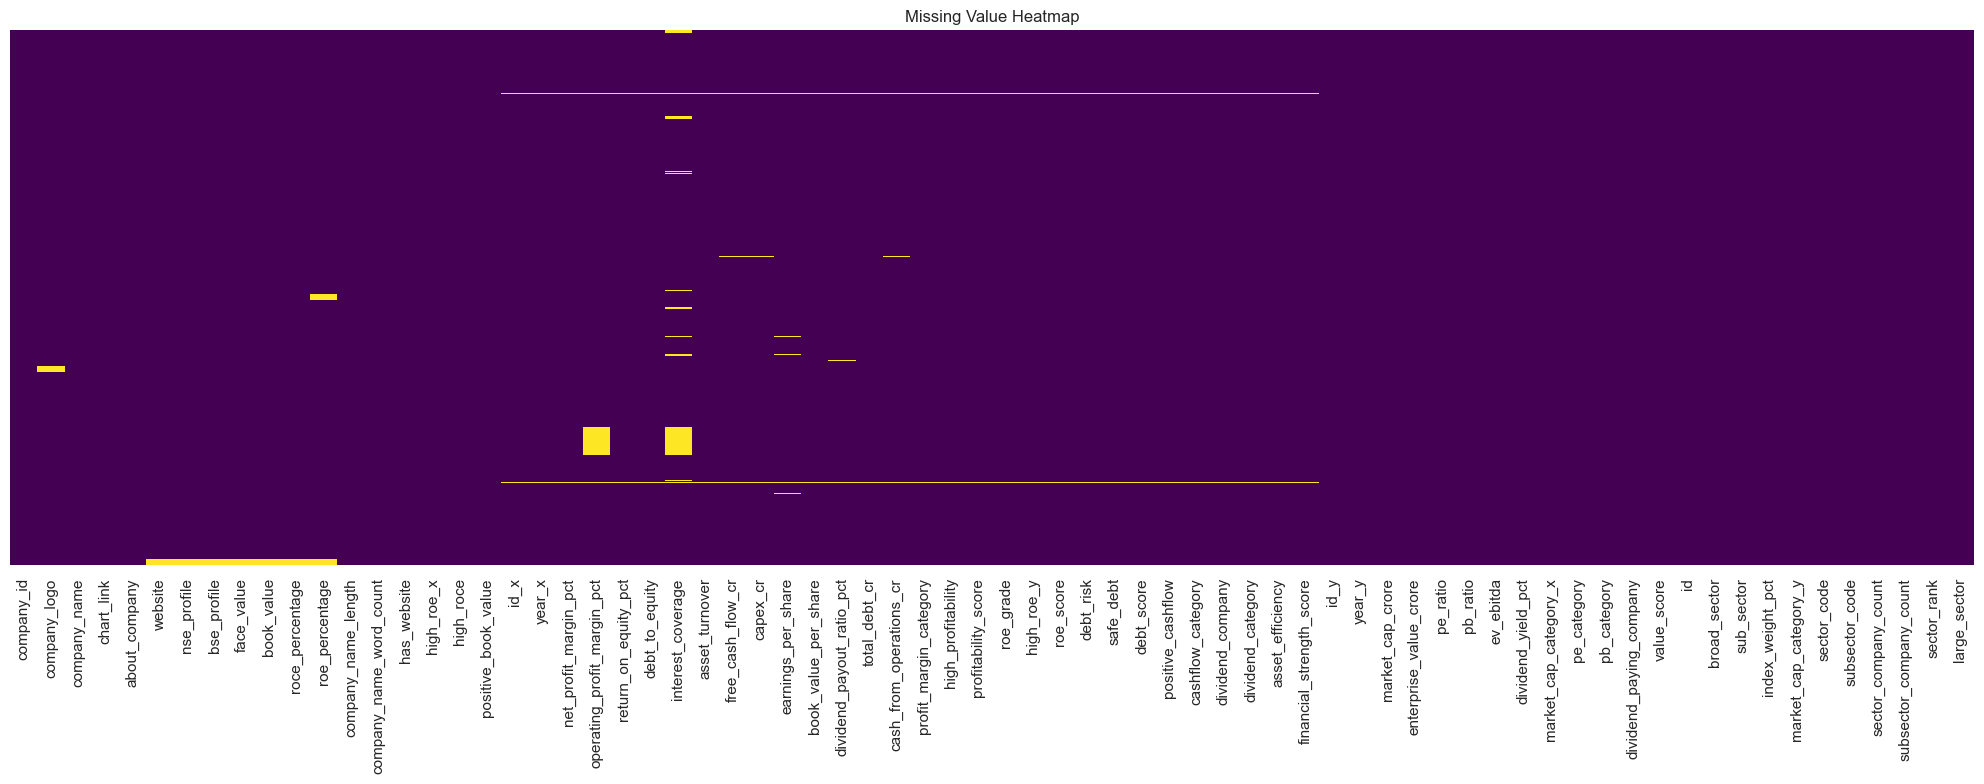

In [13]:
plt.figure(figsize=(20,8))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missing Value Heatmap")

plt.tight_layout()

plt.show()

In [14]:
duplicates = df[df.duplicated()]

print("Duplicate Rows :", len(duplicates))

duplicates.head()

Duplicate Rows : 0


,company_id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage,company_name_length,company_name_word_count,has_website,high_roe_x,high_roce,positive_book_value,id_x,year_x,net_profit_margin_pct,operating_profit_margin_pct,return_on_equity_pct,debt_to_equity,interest_coverage,asset_turnover,free_cash_flow_cr,capex_cr,earnings_per_share,book_value_per_share,dividend_payout_ratio_pct,total_debt_cr,cash_from_operations_cr,profit_margin_category,high_profitability,profitability_score,roe_grade,high_roe_y,roe_score,debt_risk,safe_debt,debt_score,positive_cashflow,cashflow_category,dividend_company,dividend_category,asset_efficiency,financial_strength_score,id_y,year_y,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct,market_cap_category_x,pe_category,pb_category,dividend_paying_company,value_score,id,broad_sector,sub_sector,index_weight_pct,market_cap_category_y,sector_code,subsector_code,sector_company_count,subsector_company_count,sector_rank,large_sector


In [15]:
print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6972 entries, 0 to 6971
Data columns (total 72 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   company_id                   6972 non-null   object 
 1   company_logo                 6900 non-null   object 
 2   company_name                 6972 non-null   object 
 3   chart_link                   6972 non-null   object 
 4   about_company                6972 non-null   object 
 5   website                      6900 non-null   object 
 6   nse_profile                  6900 non-null   object 
 7   bse_profile                  6900 non-null   object 
 8   face_value                   6900 non-null   float64
 9   book_value                   6900 non-null   float64
 10  roce_percentage              6900 non-null   float64
 11  roe_percentage               6828 non-null   float64
 12  company_name_length          6972 non-null   int64  
 13  company_name_word_

### Module 2 — Univariate Analysis.

In [16]:
from pathlib import Path

FIGURE_DIR = Path("../reports/figures/eda")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURE_DIR)

..\reports\figures\eda


In [17]:
important_numeric = [

    "net_profit_margin_pct",
    "operating_profit_margin_pct",
    "return_on_equity_pct",
    "debt_to_equity",
    "asset_turnover",
    "free_cash_flow_cr",
    "market_cap_crore",
    "enterprise_value_crore",
    "pe_ratio",
    "pb_ratio",
    "ev_ebitda",
    "dividend_yield_pct",
    "financial_strength_score"

]

## Histograms

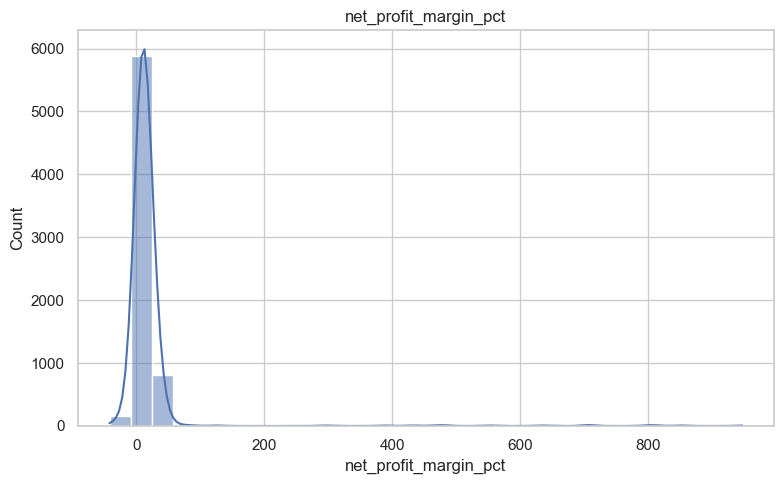

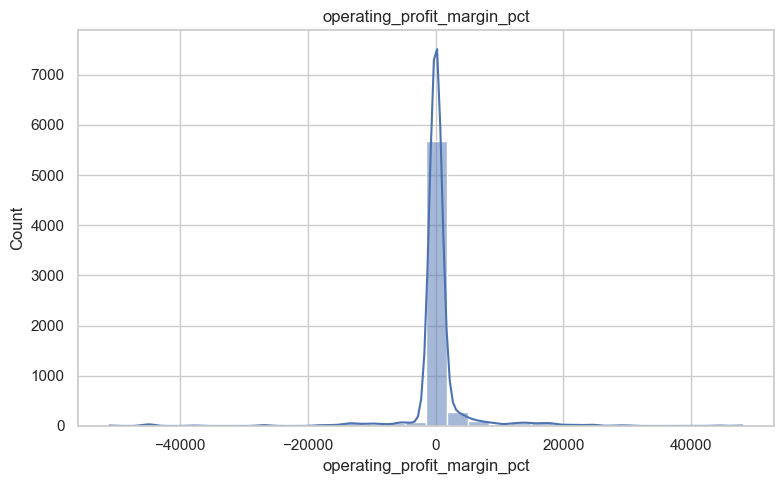

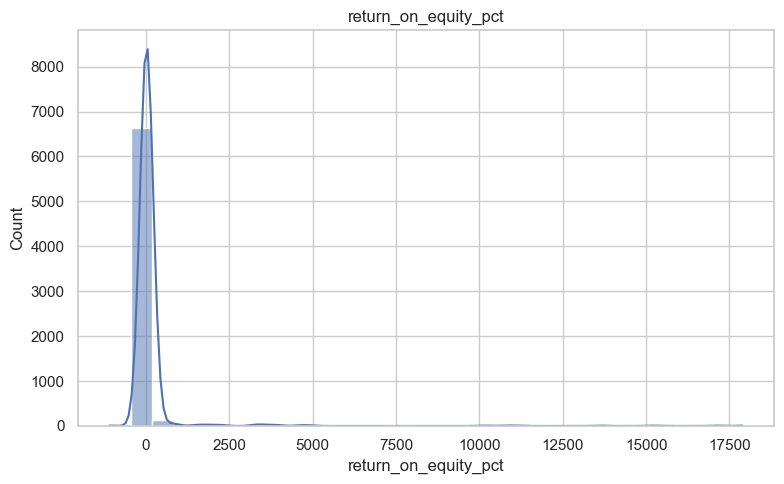

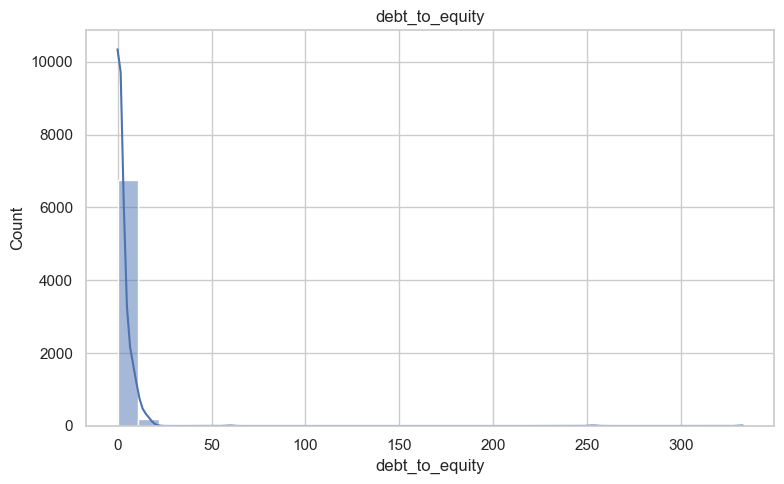

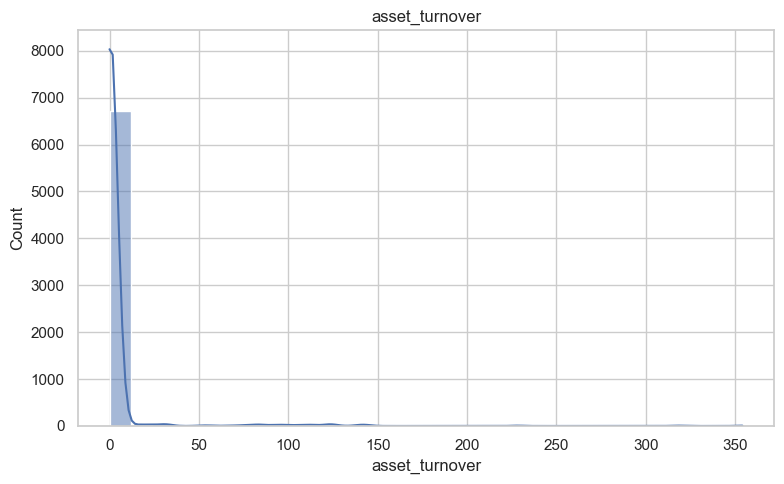

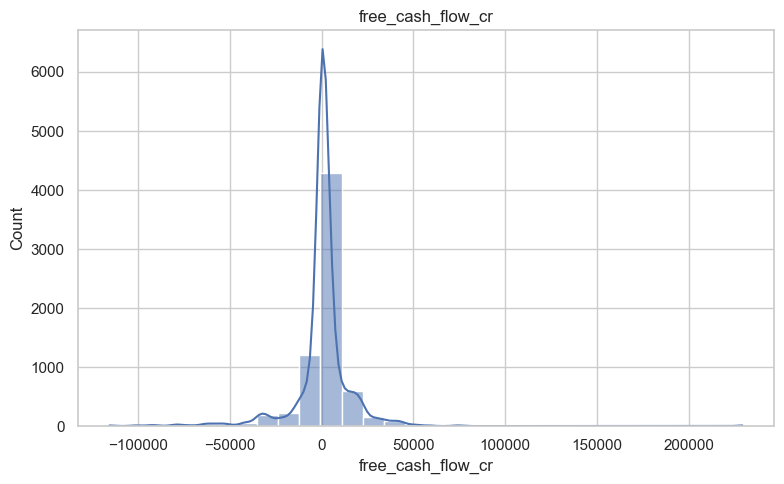

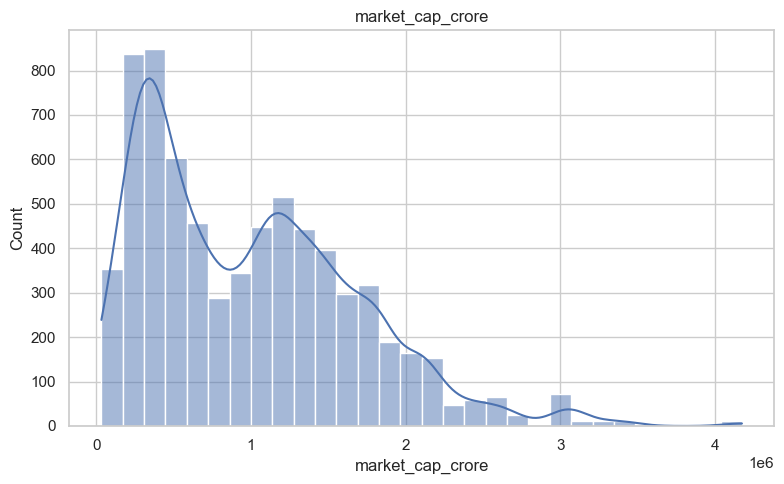

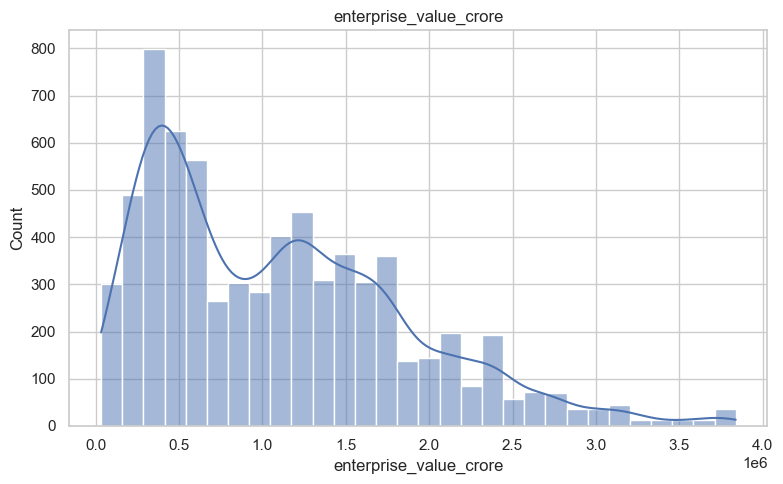

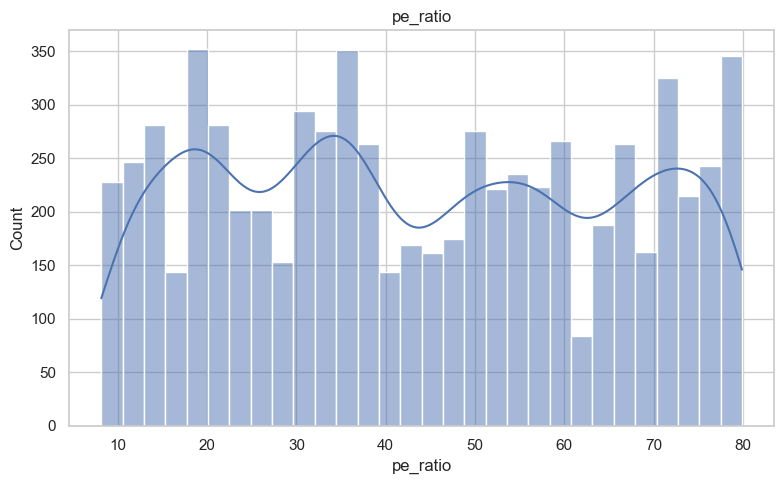

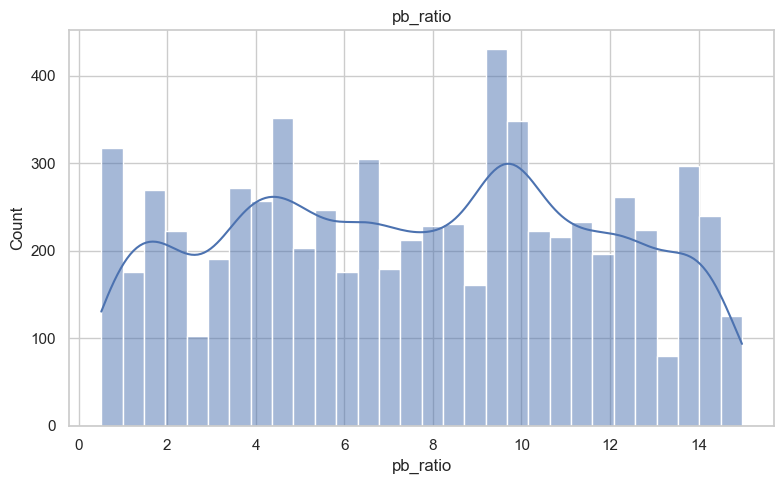

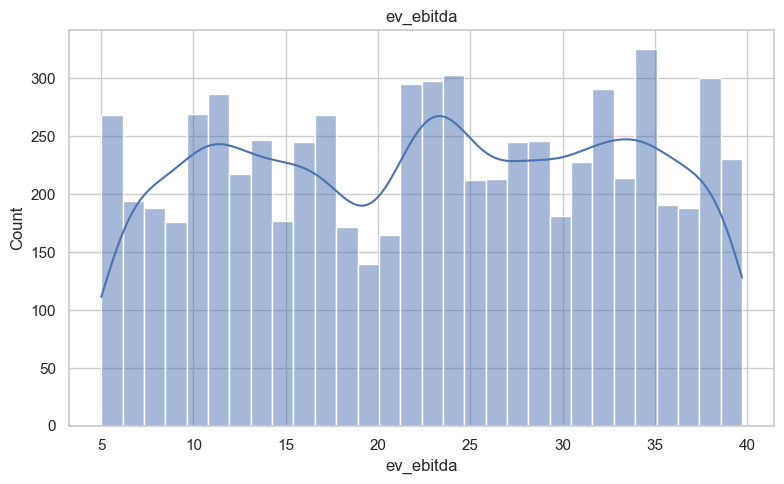

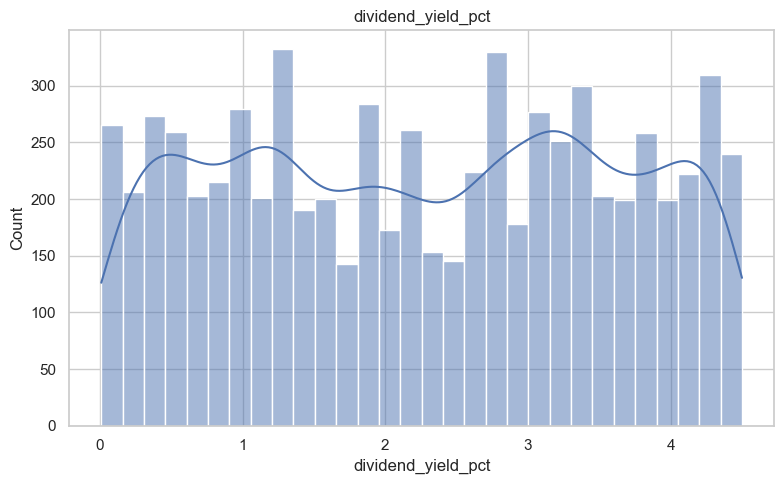

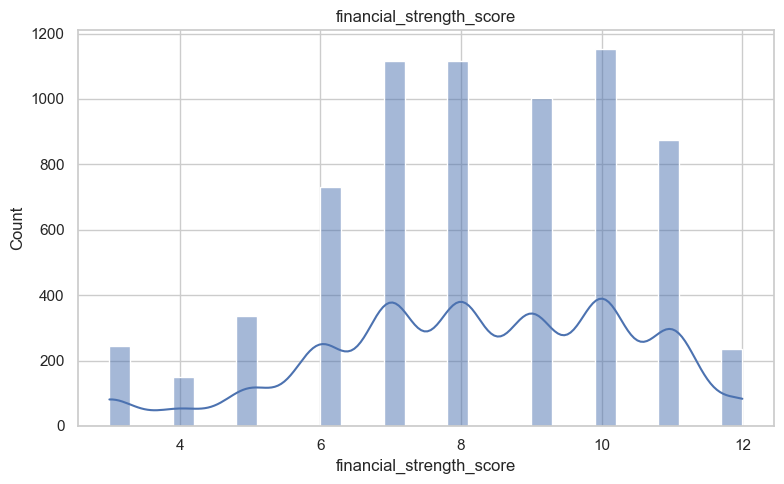

In [18]:
for col in important_numeric:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(col)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{col}_histogram.png",
        dpi=300
    )

    plt.show()

## Boxplots

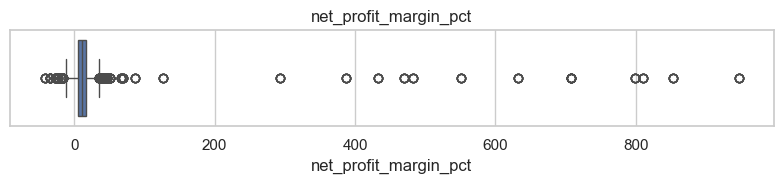

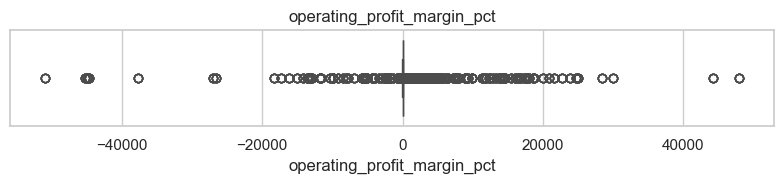

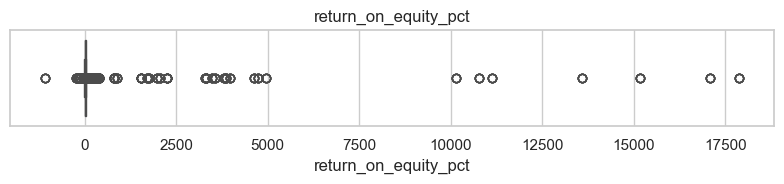

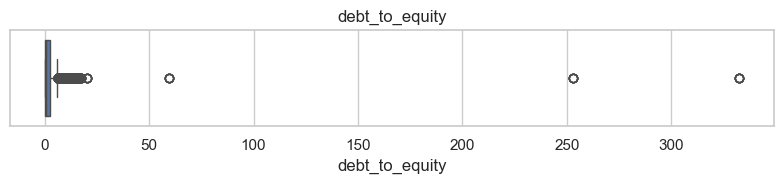

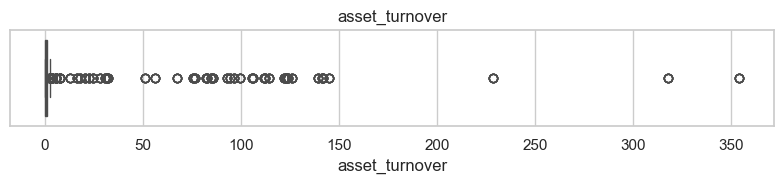

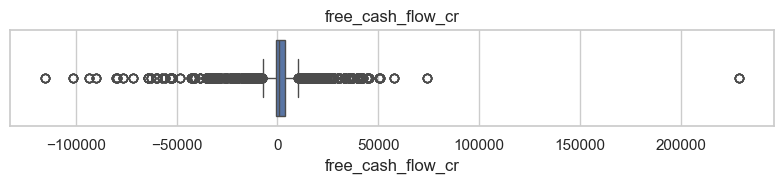

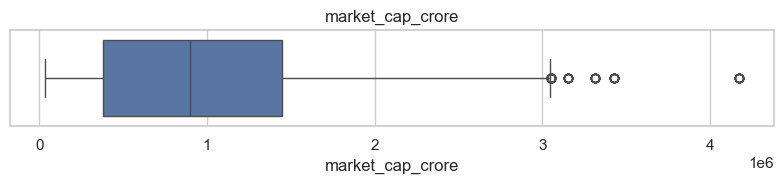

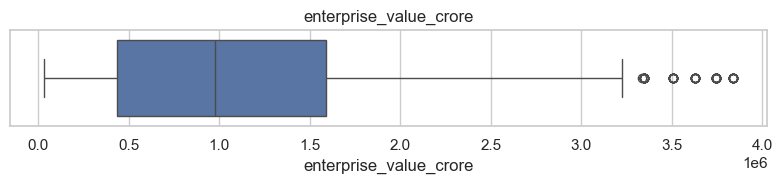

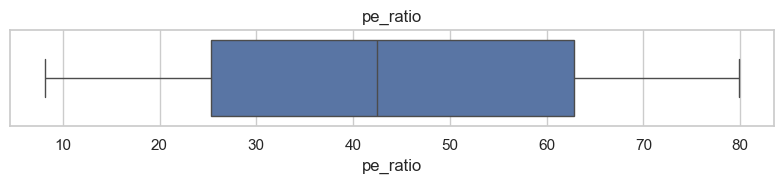

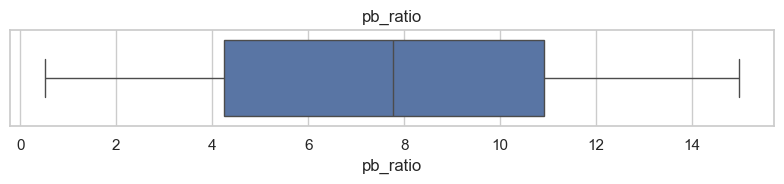

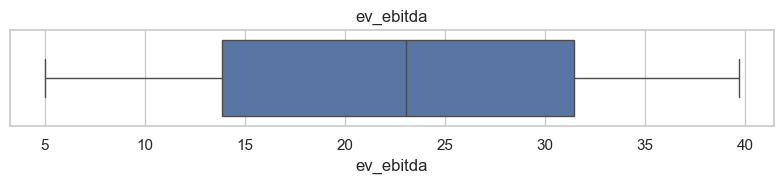

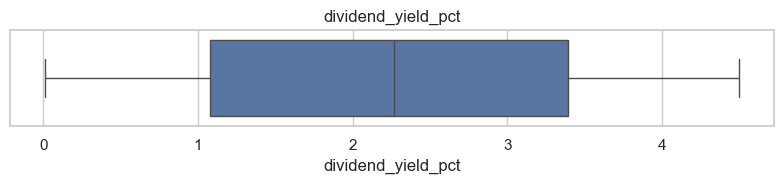

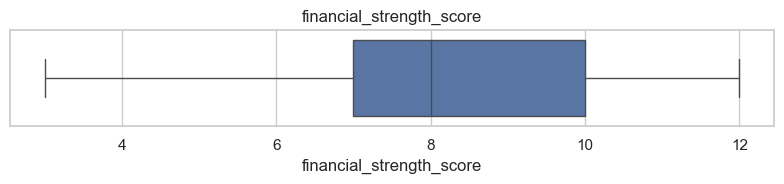

In [19]:
for col in important_numeric:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{col}_boxplot.png",
        dpi=300
    )

    plt.show()

## Distribution Statistics

In [20]:
distribution_summary = df[important_numeric].describe().T

distribution_summary["Missing"] = df[important_numeric].isnull().sum()

distribution_summary["Skewness"] = df[important_numeric].skew()

distribution_summary["Kurtosis"] = df[important_numeric].kurt()

distribution_summary

,count,mean,std,min,25%,50%,75%,max,Missing,Skewness,Kurtosis
net_profit_margin_pct,6954.0,1.891123e+01,68.311996,-42.1500,5.22000,11.2500,1.725000e+01,9.475100e+02,18,10.066647,108.177278
operating_profit_margin_pct,6594.0,3.543649e+02,5562.363781,-50971.0000,13.00000,21.0000,4.100000e+01,4.797100e+04,378,-1.273138,36.000063
return_on_equity_pct,6960.0,1.557722e+02,1156.439594,-1094.1500,10.66750,16.9650,2.513000e+01,1.788636e+04,12,11.401296,144.047728
debt_to_equity,6960.0,2.697757e+00,12.754324,0.0000,0.04615,0.5716,2.482900e+00,3.325938e+02,12,21.542969,511.420314
asset_turnover,6954.0,4.188294e+00,22.192186,0.0004,0.23970,0.6997,1.177600e+00,3.539615e+02,18,9.173403,106.513759
free_cash_flow_cr,6948.0,7.055898e+02,16272.455719,-115427.0000,-740.00000,724.0000,3.622000e+03,2.290490e+05,24,0.915044,41.475898
market_cap_crore,6972.0,9.926570e+05,695398.261437,33360.2300,378605.83000,901096.1300,1.446057e+06,4.173085e+06,0,0.874646,0.677602
enterprise_value_crore,6972.0,1.095635e+06,772180.279786,33277.0600,436528.59250,976938.1400,1.586505e+06,3.837414e+06,0,0.854269,0.314758
pe_ratio,6972.0,4.385875e+01,21.338552,8.1400,25.37000,42.5100,6.287750e+01,7.991000e+01,0,0.063896,-1.242243
pb_ratio,6972.0,7.624862e+00,4.070063,0.5100,4.24000,7.7700,1.091000e+01,1.498000e+01,0,-0.017689,-1.123940


## Outlier Count (IQR)

In [21]:
outlier_summary = []

for col in important_numeric:

    q1 = df[col].quantile(0.25)

    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    outlier_summary.append(
        {
            "Feature": col,
            "Outliers": outliers
        }
    )

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Outliers",
    ascending=False
)

,Feature,Outliers
5,free_cash_flow_cr,1698
1,operating_profit_margin_pct,1554
3,debt_to_equity,1008
2,return_on_equity_pct,774
0,net_profit_margin_pct,396
4,asset_turnover,396
6,market_cap_crore,83
7,enterprise_value_crore,73
8,pe_ratio,0
9,pb_ratio,0


In [22]:
missing_df = pd.DataFrame({

    "Feature": important_numeric,

    "Missing Values":
    df[important_numeric].isnull().sum().values

})

missing_df

,Feature,Missing Values
0,net_profit_margin_pct,18
1,operating_profit_margin_pct,378
2,return_on_equity_pct,12
3,debt_to_equity,12
4,asset_turnover,18
5,free_cash_flow_cr,24
6,market_cap_crore,0
7,enterprise_value_crore,0
8,pe_ratio,0
9,pb_ratio,0


### Module 3 — Categorical Analysis.

In [23]:
important_categorical = [

    "broad_sector",
    "sub_sector",
    "market_cap_category_x",
    "profit_margin_category",
    "roe_grade",
    "debt_risk",
    "cashflow_category",
    "dividend_category",
    "asset_efficiency",
    "pe_category",
    "pb_category"

]

## Count Plots

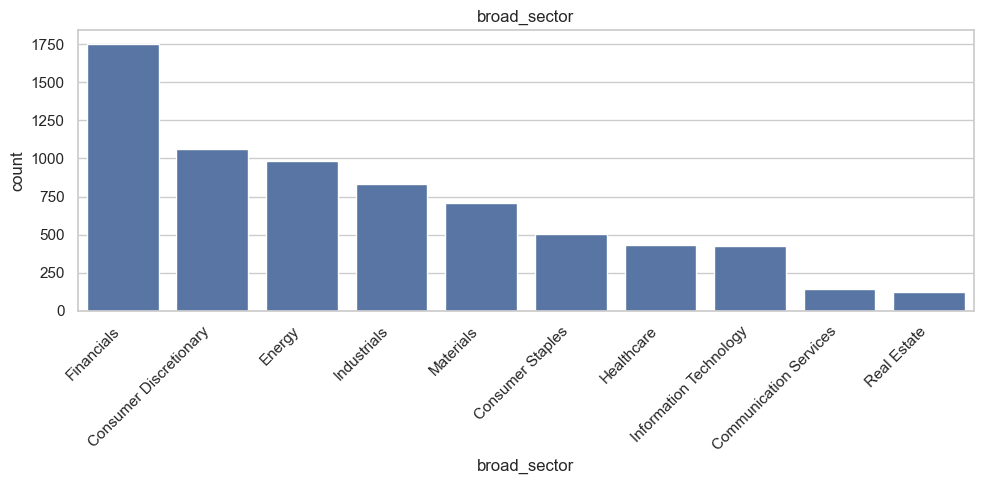

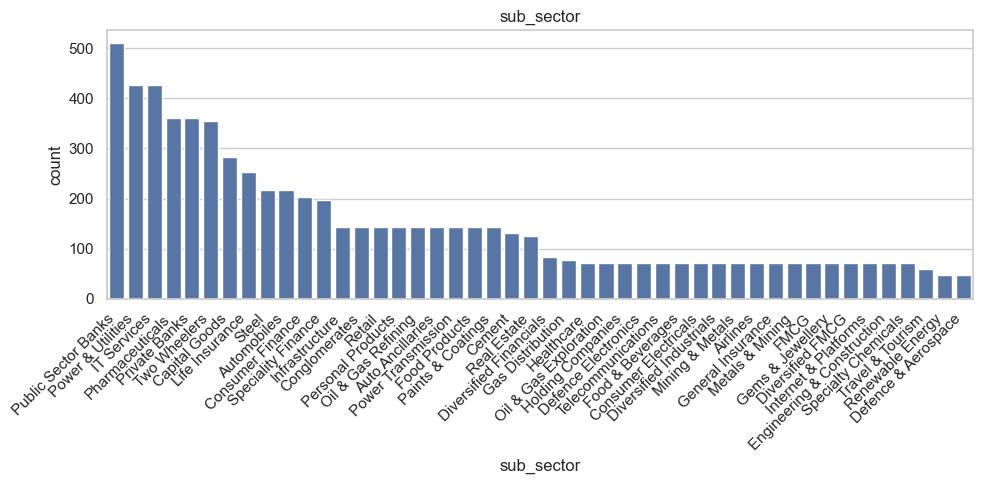

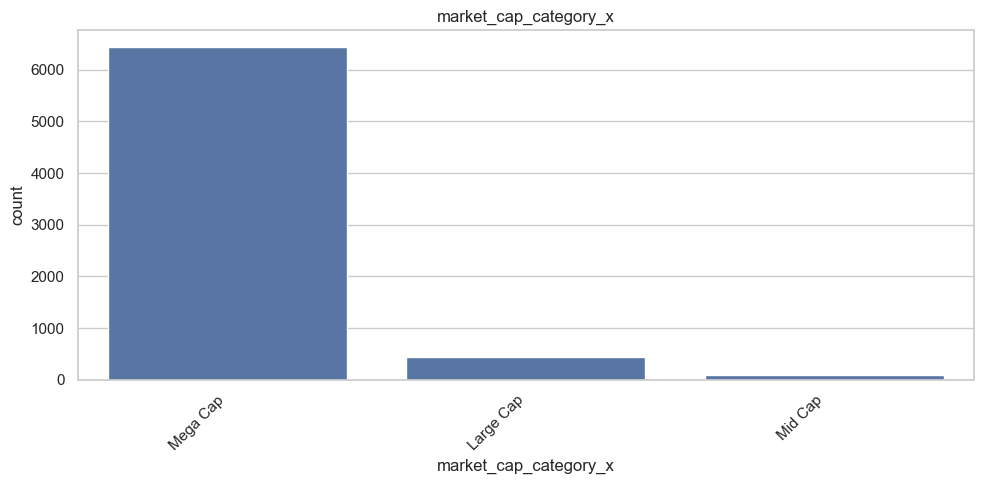

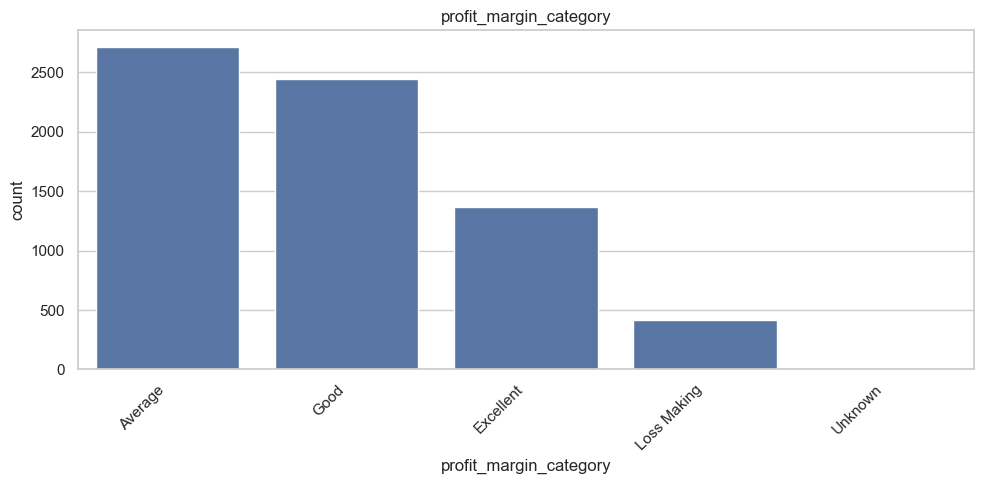

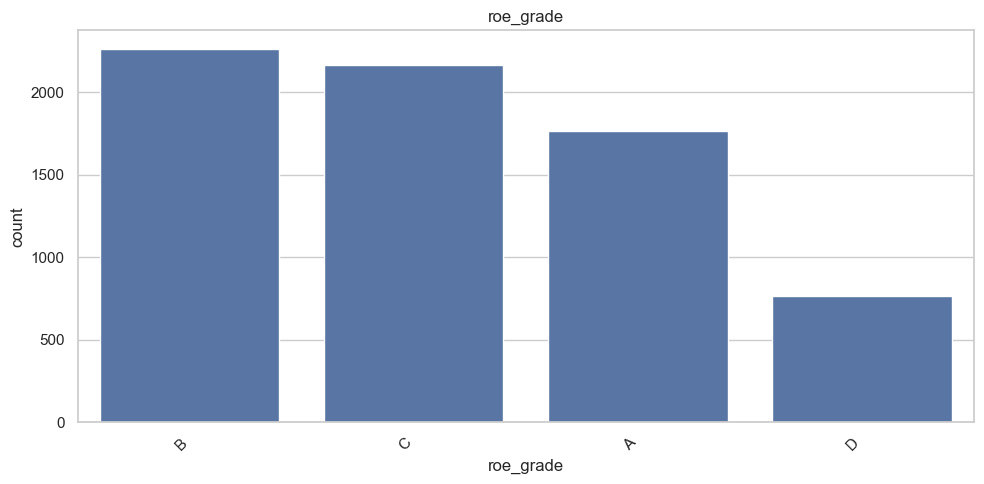

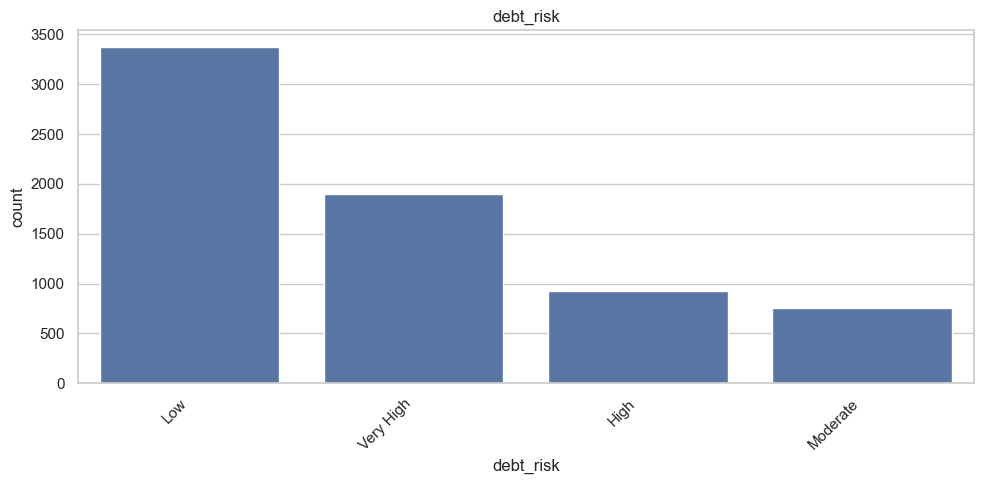

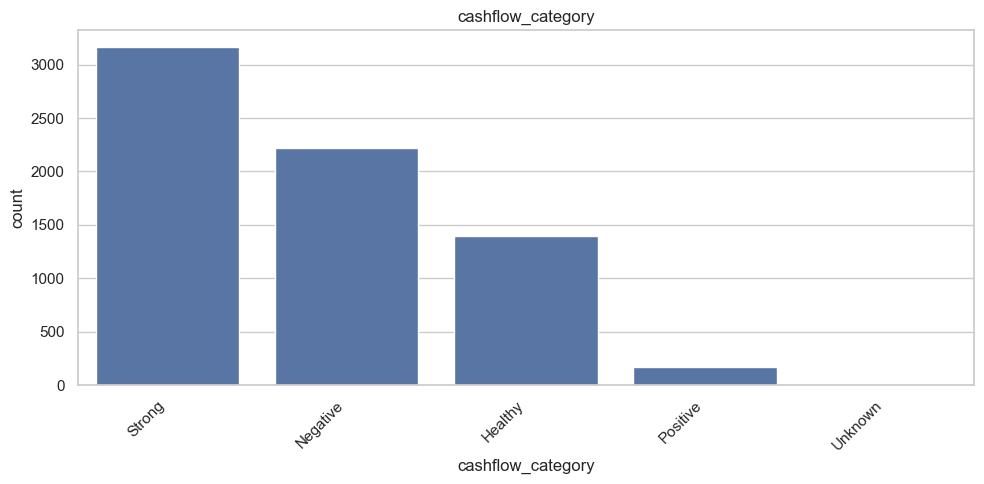

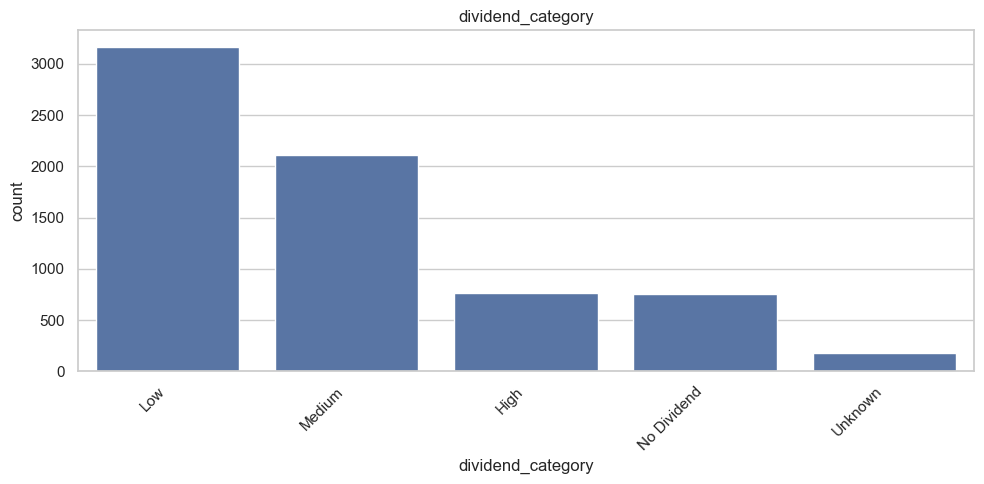

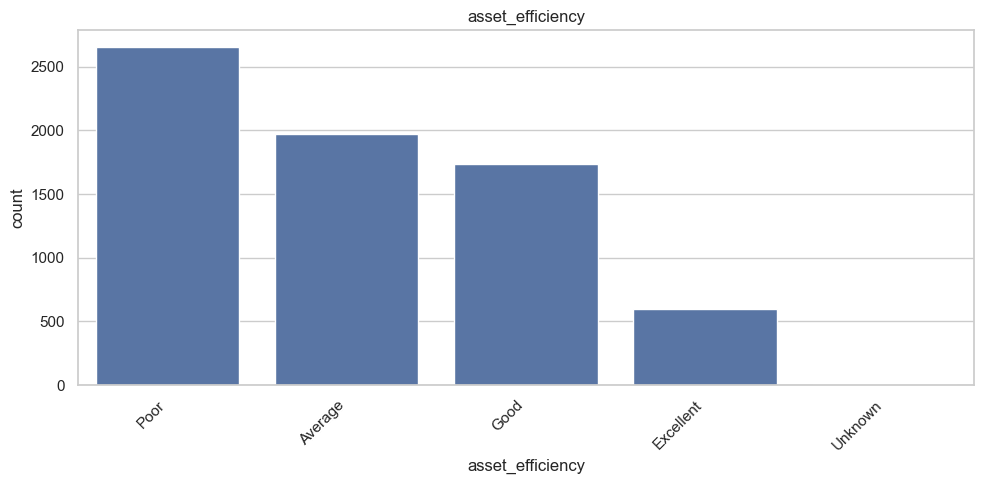

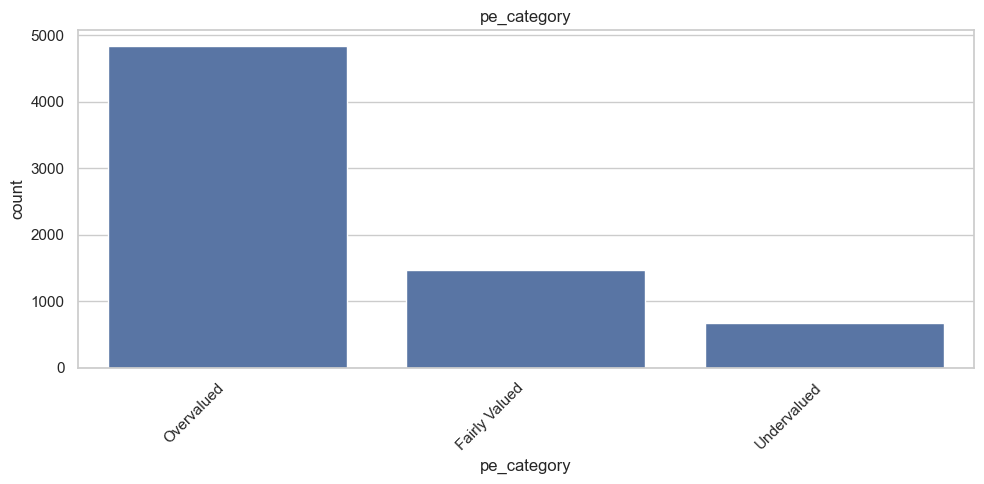

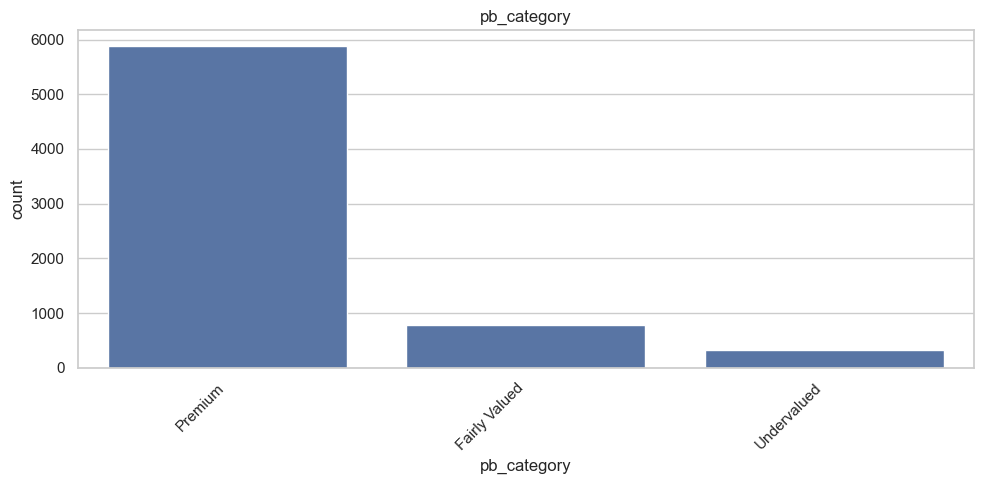

In [24]:
for col in important_categorical:

    plt.figure(figsize=(10,5))

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order
    )

    plt.xticks(rotation=45, ha="right")

    plt.title(col)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{col}_countplot.png",
        dpi=300
    )

    plt.show()

## Frequency Tables

In [25]:
for col in important_categorical:

    print("=" * 80)
    print(col)
    print("=" * 80)

    display(
        df[col]
        .value_counts()
        .to_frame("Count")
    )

broad_sector


,Count
broad_sector,
Financials,1752
Consumer Discretionary,1062
Energy,984
Industrials,834
Materials,708
Consumer Staples,504
Healthcare,432
Information Technology,426
Communication Services,144


sub_sector


,Count
sub_sector,
Public Sector Banks,510
Power & Utilities,426
IT Services,426
Pharmaceuticals,360
Private Banks,360
Two Wheelers,354
Capital Goods,282
Life Insurance,252
Steel,216


market_cap_category_x


...

,Count
asset_efficiency,
Poor,2652
Average,1974
Good,1734
Excellent,594
Unknown,6


pe_category


,Count
pe_category,
Overvalued,4834
Fairly Valued,1466
Undervalued,672


pb_category


,Count
pb_category,
Premium,5873
Fairly Valued,782
Undervalued,317


## Percentage Distribution

In [26]:
for col in important_categorical:

    print("=" * 80)
    print(col)
    print("=" * 80)

    display(
        (
            df[col]
            .value_counts(normalize=True)
            * 100
        )
        .round(2)
        .to_frame("Percentage")
    )

broad_sector


,Percentage
broad_sector,
Financials,25.13
Consumer Discretionary,15.23
Energy,14.11
Industrials,11.96
Materials,10.15
Consumer Staples,7.23
Healthcare,6.20
Information Technology,6.11
Communication Services,2.07


sub_sector


,Percentage
sub_sector,
Public Sector Banks,7.31
Power & Utilities,6.11
IT Services,6.11
Pharmaceuticals,5.16
Private Banks,5.16
Two Wheelers,5.08
Capital Goods,4.04
Life Insurance,3.61
Steel,3.10


market_cap_category_x


...

,Percentage
asset_efficiency,
Poor,38.10
Average,28.36
Good,24.91
Excellent,8.53
Unknown,0.09


pe_category


,Percentage
pe_category,
Overvalued,69.33
Fairly Valued,21.03
Undervalued,9.64


pb_category


,Percentage
pb_category,
Premium,84.24
Fairly Valued,11.22
Undervalued,4.55


## Pie Charts (Only Low Cardinality)

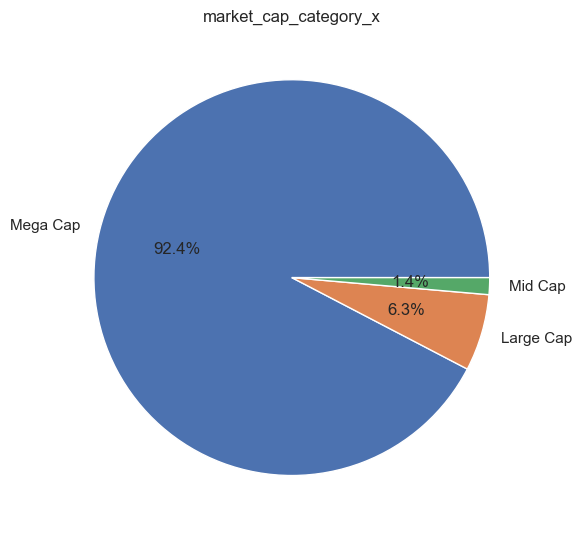

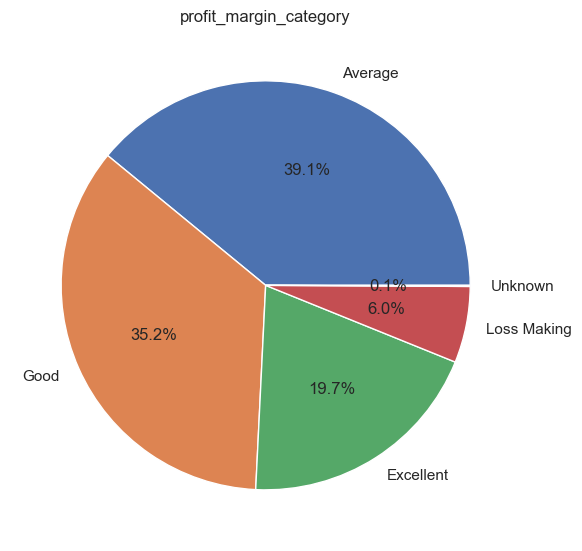

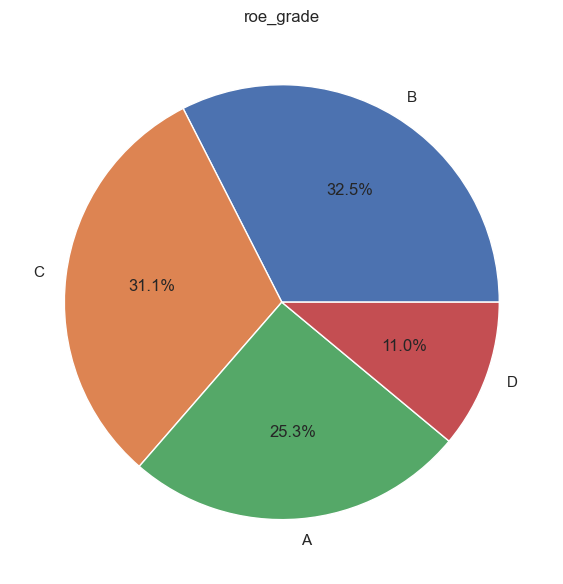

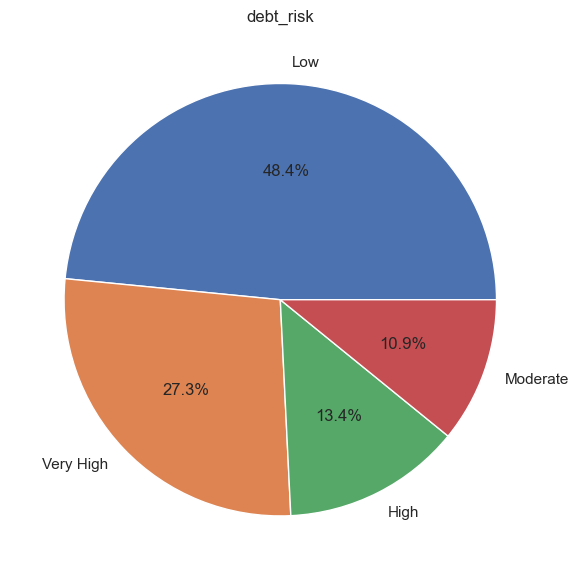

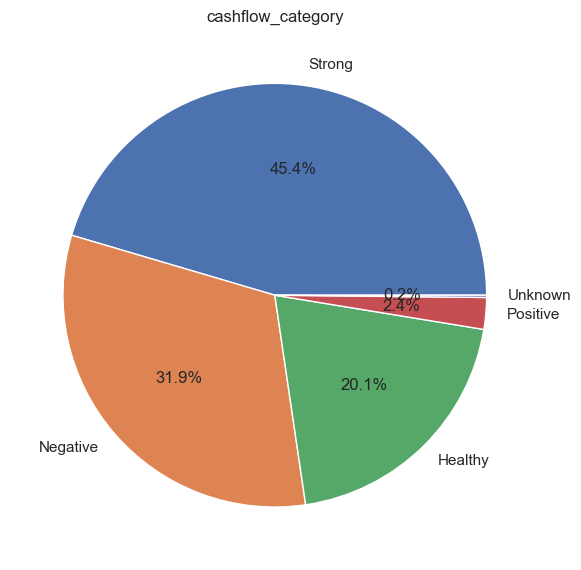

In [27]:
pie_features = [

    "market_cap_category_x",
    "profit_margin_category",
    "roe_grade",
    "debt_risk",
    "cashflow_category"

]

for col in pie_features:

    plt.figure(figsize=(6,6))

    df[col].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%"
    )

    plt.ylabel("")

    plt.title(col)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{col}_piechart.png",
        dpi=300
    )

    plt.show()

## Top 15 Companies by Frequency

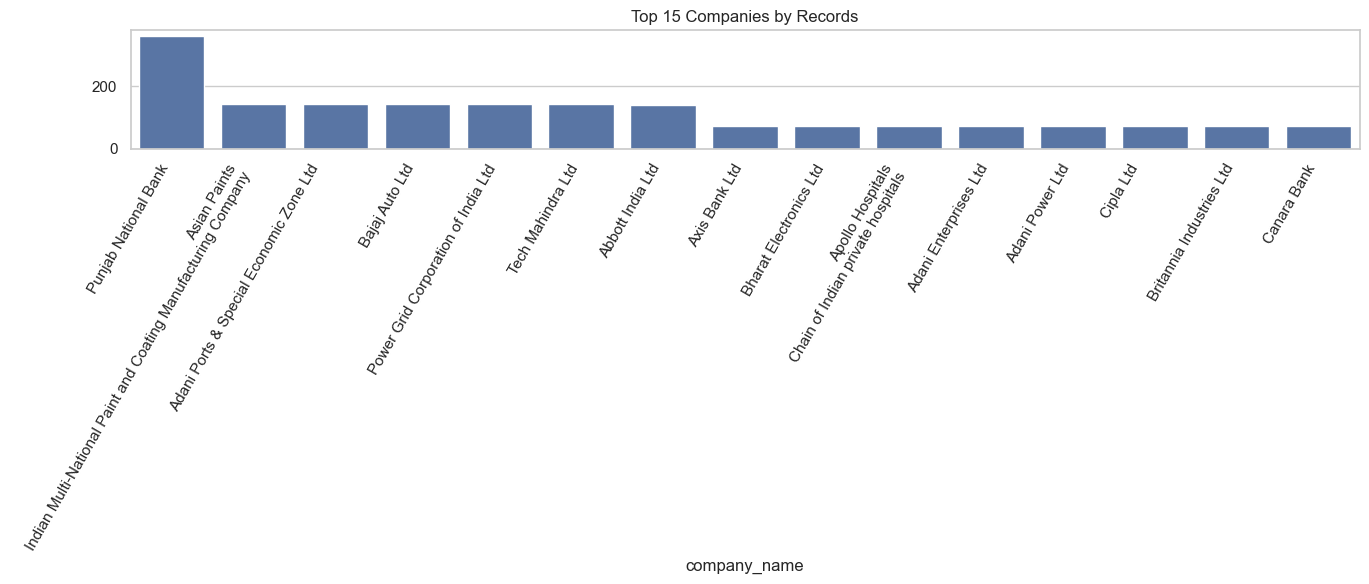

In [28]:
plt.figure(figsize=(14,6))

company_counts = (
    df["company_name"]
    .value_counts()
    .head(15)
)

sns.barplot(
    x=company_counts.index,
    y=company_counts.values
)

plt.xticks(rotation=60, ha="right")

plt.title("Top 15 Companies by Records")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top_companies_records.png",
    dpi=300
)

plt.show()

## Sector Distribution

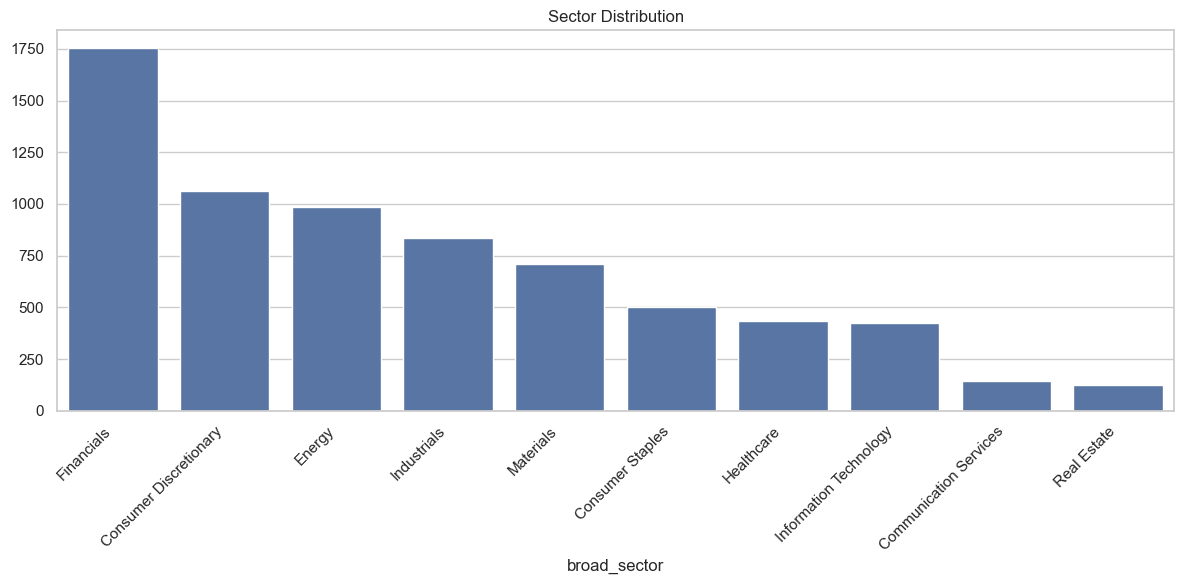

In [29]:
plt.figure(figsize=(12,6))

sector_counts = df["broad_sector"].value_counts()

sns.barplot(

    x=sector_counts.index,

    y=sector_counts.values

)

plt.xticks(rotation=45, ha="right")

plt.title("Sector Distribution")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "sector_distribution.png",

    dpi=300

)

plt.show()

### Module 4 — Correlation Analysis

In [30]:
correlation_features = [

    "net_profit_margin_pct",
    "operating_profit_margin_pct",
    "return_on_equity_pct",
    "debt_to_equity",
    "asset_turnover",
    "free_cash_flow_cr",
    "market_cap_crore",
    "enterprise_value_crore",
    "pe_ratio",
    "pb_ratio",
    "ev_ebitda",
    "dividend_yield_pct",
    "financial_strength_score",
    "roe_percentage",
    "roce_percentage",
    "book_value"

]

corr_df = df[correlation_features]

corr_df.head()

,net_profit_margin_pct,operating_profit_margin_pct,return_on_equity_pct,debt_to_equity,asset_turnover,free_cash_flow_cr,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct,financial_strength_score,roe_percentage,roce_percentage,book_value
0,8.77,12.0,22.41,0.0,1.8225,42.0,844312.98,814410.48,19.29,14.26,22.84,0.84,9.0,34.9,46.0,1657.0
1,8.77,12.0,22.41,0.0,1.8225,42.0,923674.33,1120679.72,67.54,13.03,24.93,3.90,9.0,34.9,46.0,1657.0
2,8.77,12.0,22.41,0.0,1.8225,42.0,1020674.09,1166450.81,62.63,6.67,7.58,1.58,9.0,34.9,46.0,1657.0
3,8.77,12.0,22.41,0.0,1.8225,42.0,1185994.82,1158637.42,18.68,4.75,6.12,3.35,9.0,34.9,46.0,1657.0
4,8.77,12.0,22.41,0.0,1.8225,42.0,1161513.28,1103083.77,58.34,12.72,5.70,1.05,9.0,34.9,46.0,1657.0


## Correlation Matrix

In [31]:
corr_matrix = corr_df.corr(numeric_only=True)

corr_matrix

,net_profit_margin_pct,operating_profit_margin_pct,return_on_equity_pct,debt_to_equity,asset_turnover,free_cash_flow_cr,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct,financial_strength_score,roe_percentage,roce_percentage,book_value
net_profit_margin_pct,1.000000,-0.001315,-0.006390,-0.034373,-0.020469,-0.010113,0.043649,0.044168,0.040095,-0.015244,-0.071228,-0.005239,0.188379,-0.035410,-0.037107,0.488967
operating_profit_margin_pct,-0.001315,1.000000,0.002776,-0.054783,0.015262,-0.069657,-0.048438,-0.052501,-0.037289,0.001975,-0.007633,-0.019939,0.183381,0.075102,0.112802,-0.008248
return_on_equity_pct,-0.006390,0.002776,1.000000,0.004074,0.836891,0.003228,0.028890,0.031973,0.023311,0.016250,0.041906,0.062188,0.043838,0.045950,0.058962,-0.052666
debt_to_equity,-0.034373,-0.054783,0.004074,1.000000,-0.020213,-0.003996,-0.032526,-0.033181,-0.028620,-0.028803,-0.008206,0.009041,-0.186968,0.084132,0.004276,-0.058961
asset_turnover,-0.020469,0.015262,0.836891,-0.020213,1.000000,0.006054,0.055958,0.060438,0.023479,0.022122,0.044699,0.060261,0.079261,0.060500,0.069439,-0.056395
free_cash_flow_cr,-0.010113,-0.069657,0.003228,-0.003996,0.006054,1.000000,-0.105949,-0.095036,0.008239,0.032181,-0.035948,0.059710,0.108175,0.069945,0.118603,-0.038181
market_cap_crore,0.043649,-0.048438,0.028890,-0.032526,0.055958,-0.105949,1.000000,0.982547,-0.106241,-0.021212,0.050837,-0.001718,-0.009187,-0.011033,-0.016505,0.165693
enterprise_value_crore,0.044168,-0.052501,0.031973,-0.033181,0.060438,-0.095036,0.982547,1.000000,-0.097358,-0.011079,0.049710,0.010661,-0.010283,-0.018348,-0.021803,0.153375
pe_ratio,0.040095,-0.037289,0.023311,-0.028620,0.023479,0.008239,-0.106241,-0.097358,1.000000,-0.031087,0.068954,-0.037085,0.048727,0.032015,0.037526,-0.011815
pb_ratio,-0.015244,0.001975,0.016250,-0.028803,0.022122,0.032181,-0.021212,-0.011079,-0.031087,1.000000,-0.049325,0.077506,-0.029438,-0.054148,-0.007369,-0.000588


## Correlation Heatmap

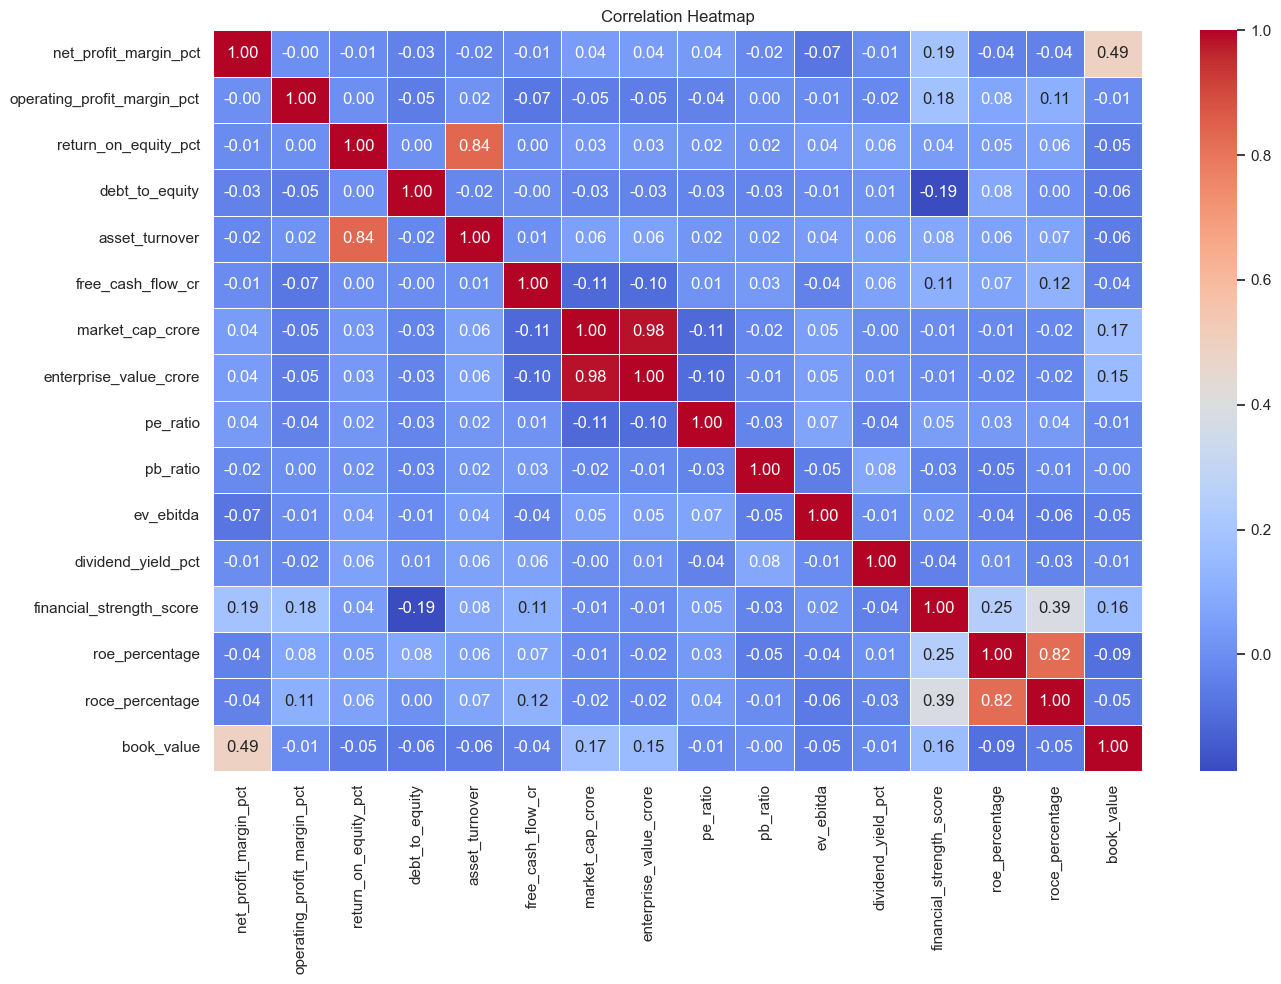

In [32]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "correlation_heatmap.png",
    dpi=300
)

plt.show()

## Highly Correlated Features

In [33]:
corr_pairs = (
    corr_matrix
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[
    corr_pairs != 1
]

corr_pairs.head(30)

enterprise_value_crore       market_cap_crore               0.982547
market_cap_crore             enterprise_value_crore         0.982547
return_on_equity_pct         asset_turnover                 0.836891
asset_turnover               return_on_equity_pct           0.836891
roe_percentage               roce_percentage                0.819697
roce_percentage              roe_percentage                 0.819697
net_profit_margin_pct        book_value                     0.488967
book_value                   net_profit_margin_pct          0.488967
financial_strength_score     roce_percentage                0.387101
roce_percentage              financial_strength_score       0.387101
financial_strength_score     roe_percentage                 0.246972
roe_percentage               financial_strength_score       0.246972
financial_strength_score     net_profit_margin_pct          0.188379
net_profit_margin_pct        financial_strength_score       0.188379
operating_profit_margin_pct  finan

## Profitability vs Debt

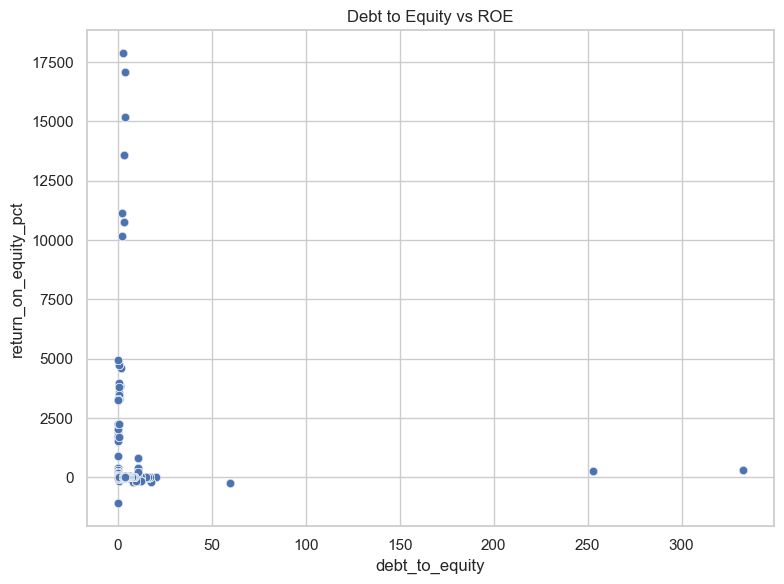

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="debt_to_equity",

    y="return_on_equity_pct",

    alpha=0.6

)

plt.title("Debt to Equity vs ROE")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "debt_vs_roe.png",
    dpi=300
)

plt.show()

## Market Cap vs Profit Margin

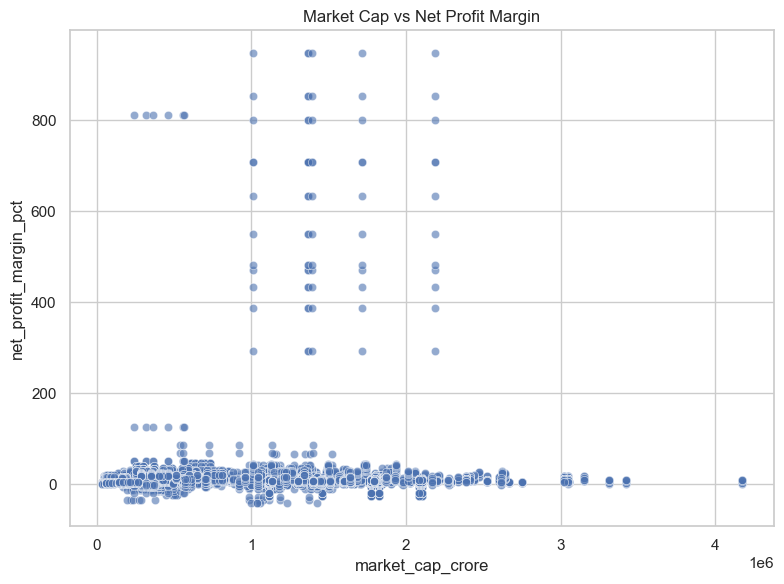

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="market_cap_crore",

    y="net_profit_margin_pct",

    alpha=0.6

)

plt.title("Market Cap vs Net Profit Margin")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "marketcap_vs_profitmargin.png",
    dpi=300
)

plt.show()

## PE Ratio vs PB Ratio

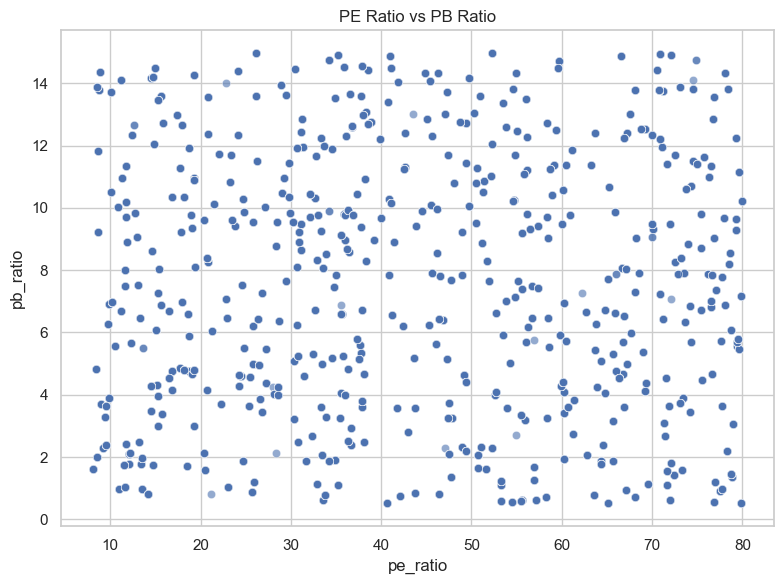

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="pe_ratio",

    y="pb_ratio",

    alpha=0.6

)

plt.title("PE Ratio vs PB Ratio")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "pe_vs_pb.png",
    dpi=300
)

plt.show()

## Enterprise Value vs Market Cap

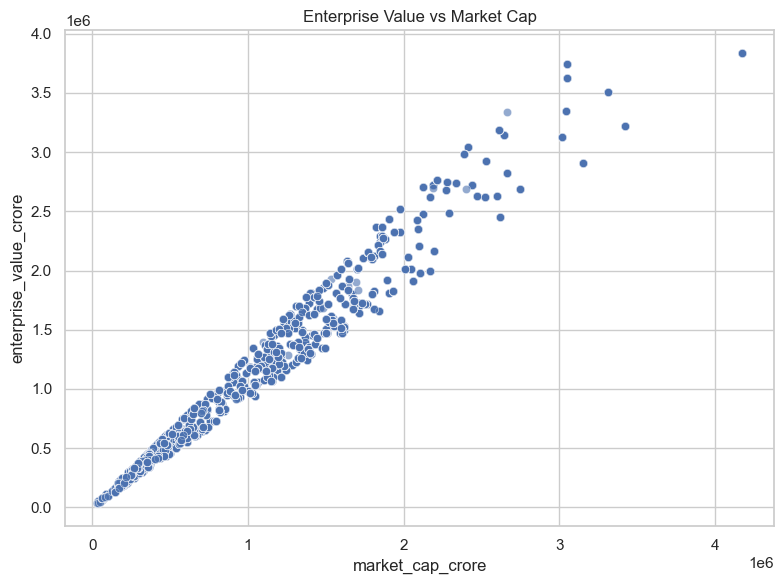

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="market_cap_crore",

    y="enterprise_value_crore",

    alpha=0.6

)

plt.title("Enterprise Value vs Market Cap")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ev_vs_marketcap.png",
    dpi=300
)

plt.show()

## Financial Strength Distribution

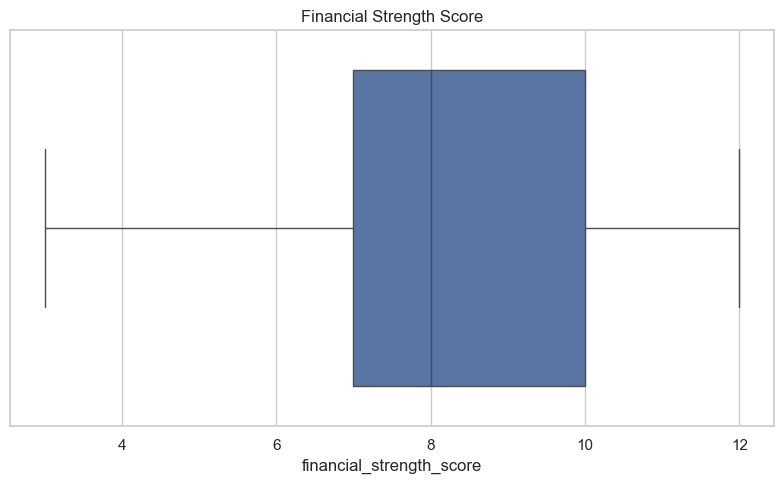

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=df,

    x="financial_strength_score"

)

plt.title("Financial Strength Score")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "financial_strength_boxplot.png",
    dpi=300
)

plt.show()

### Module 5 — Business Relationship Analysis

## Sector vs Financial Strength

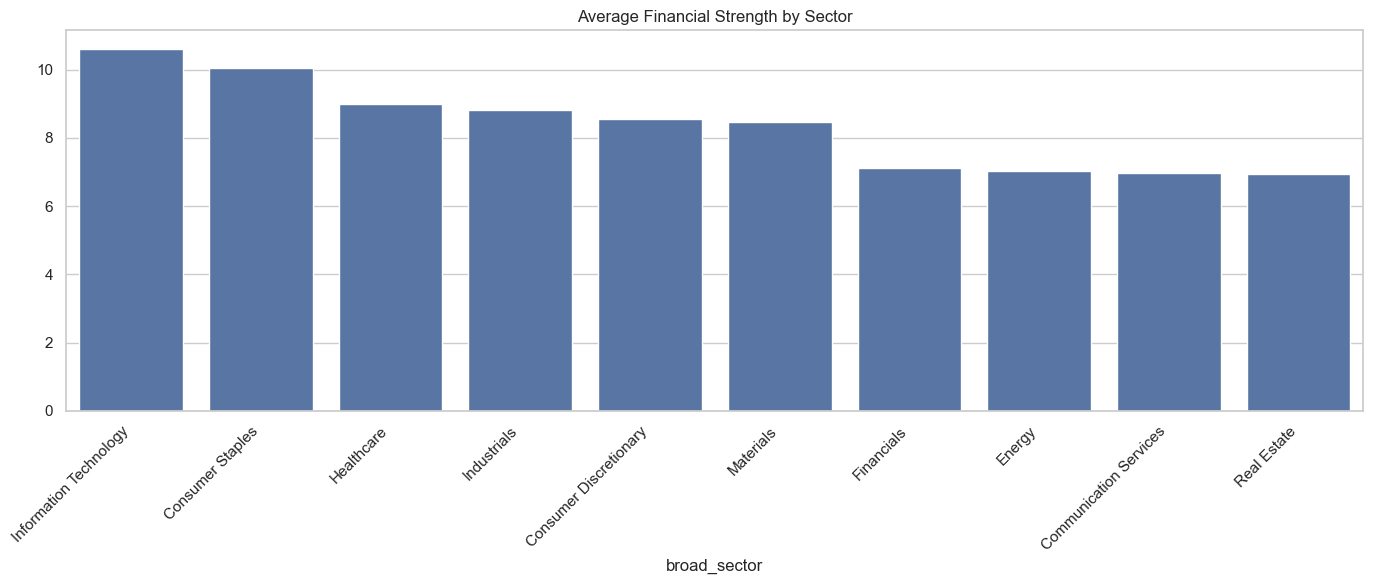

In [39]:
plt.figure(figsize=(14,6))

sector_strength = (
    df.groupby("broad_sector")["financial_strength_score"]
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=sector_strength.index,
    y=sector_strength.values
)

plt.xticks(rotation=45, ha="right")

plt.title("Average Financial Strength by Sector")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "sector_financial_strength.png",
    dpi=300
)

plt.show()


## Sector vs ROE

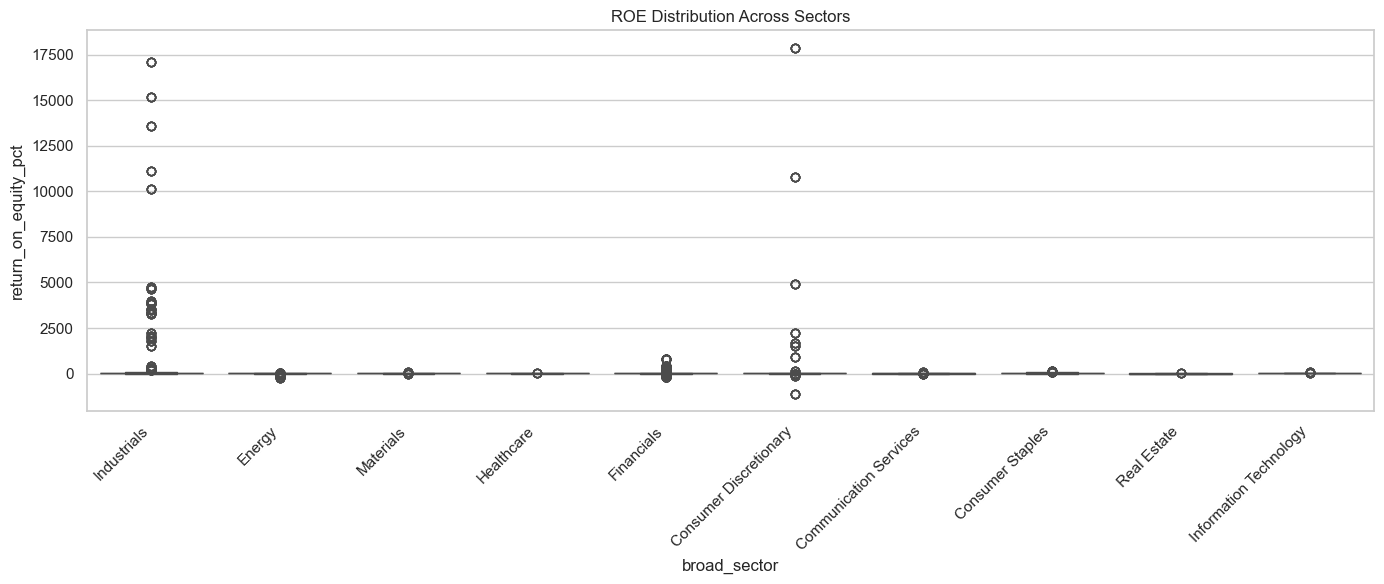

In [40]:
plt.figure(figsize=(14,6))

sns.boxplot(

    data=df,

    x="broad_sector",

    y="return_on_equity_pct"

)

plt.xticks(rotation=45, ha="right")

plt.title("ROE Distribution Across Sectors")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "sector_vs_roe.png",
    dpi=300
)

plt.show()

## Sector vs Market Cap

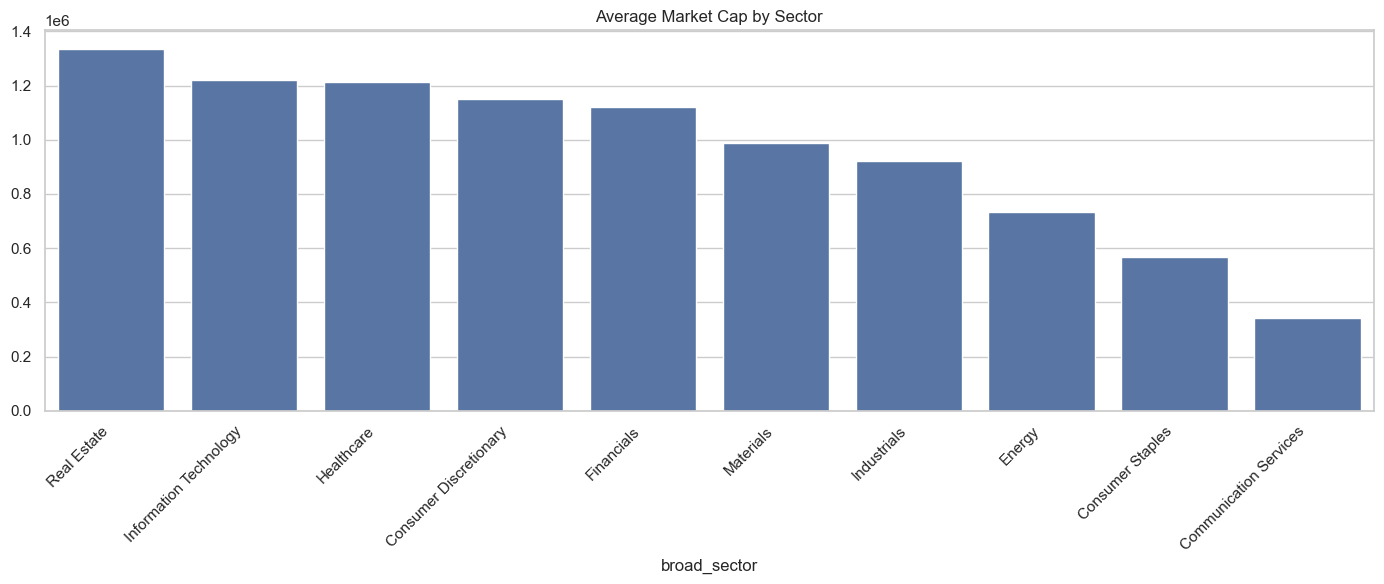

In [41]:
plt.figure(figsize=(14,6))

sector_marketcap = (
    df.groupby("broad_sector")["market_cap_crore"]
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=sector_marketcap.index,
    y=sector_marketcap.values
)

plt.xticks(rotation=45, ha="right")

plt.title("Average Market Cap by Sector")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "sector_marketcap.png",
    dpi=300
)

plt.show()

## Debt vs Financial Strength

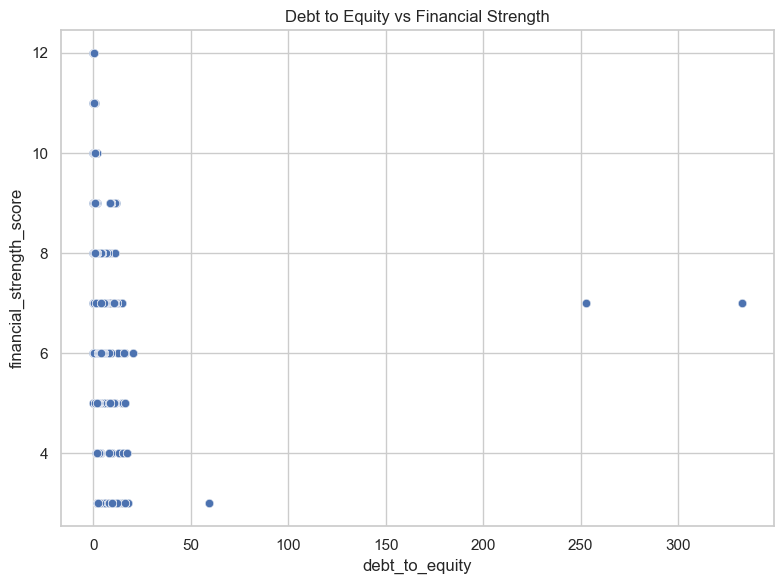

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="debt_to_equity",

    y="financial_strength_score",

    alpha=0.6

)

plt.title("Debt to Equity vs Financial Strength")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "debt_vs_strength.png",
    dpi=300
)

plt.show()

## Profit Margin vs Financial Strength

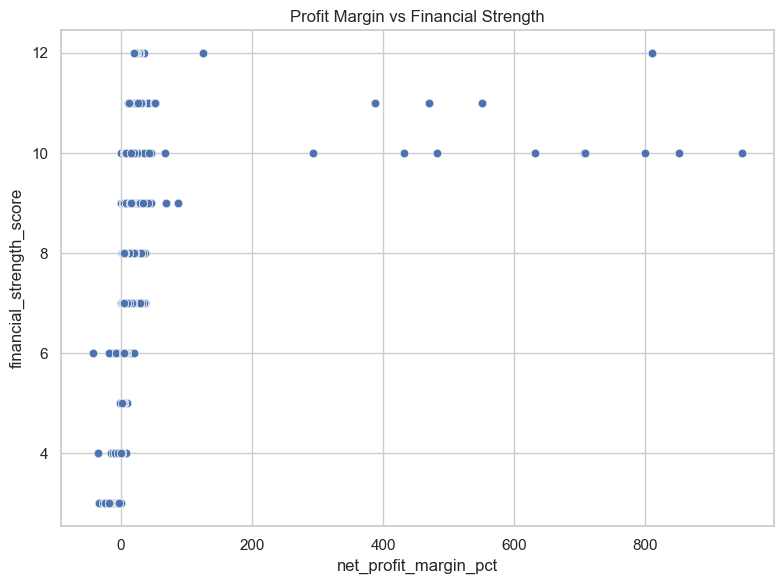

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="net_profit_margin_pct",

    y="financial_strength_score",

    alpha=0.6

)

plt.title("Profit Margin vs Financial Strength")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "profit_vs_strength.png",
    dpi=300
)

plt.show()

## Top 20 Strongest Companies

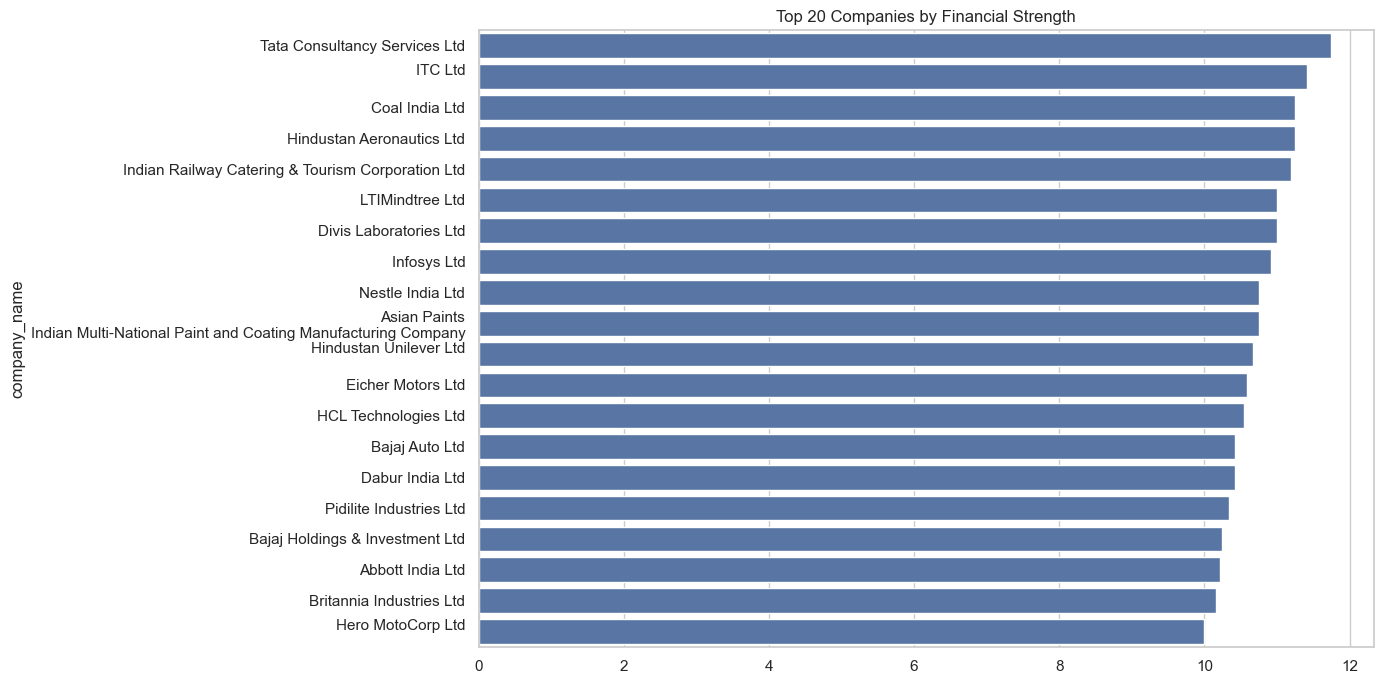

company_name
Tata Consultancy Services Ltd                                                  11.750000
ITC Ltd\n                                                                      11.416667
Coal India Ltd                                                                 11.250000
Hindustan Aeronautics Ltd                                                      11.250000
Indian Railway Catering & Tourism Corporation Ltd                              11.200000
LTIMindtree Ltd                                                                11.000000
Divis Laboratories Ltd                                                         11.000000
Infosys Ltd                                                                    10.916667
Nestle India Ltd                                                               10.750000
Asian Paints\nIndian Multi-National Paint and Coating Manufacturing Company    10.750000
Hindustan Unilever Ltd\n                                                       10.666667
Eicher M

In [44]:
top_strength = (
    df.groupby("company_name")["financial_strength_score"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14,7))

sns.barplot(

    x=top_strength.values,

    y=top_strength.index

)

plt.title("Top 20 Companies by Financial Strength")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top20_financial_strength.png",
    dpi=300
)

plt.show()

top_strength

## Top 20 Highest ROE Companies

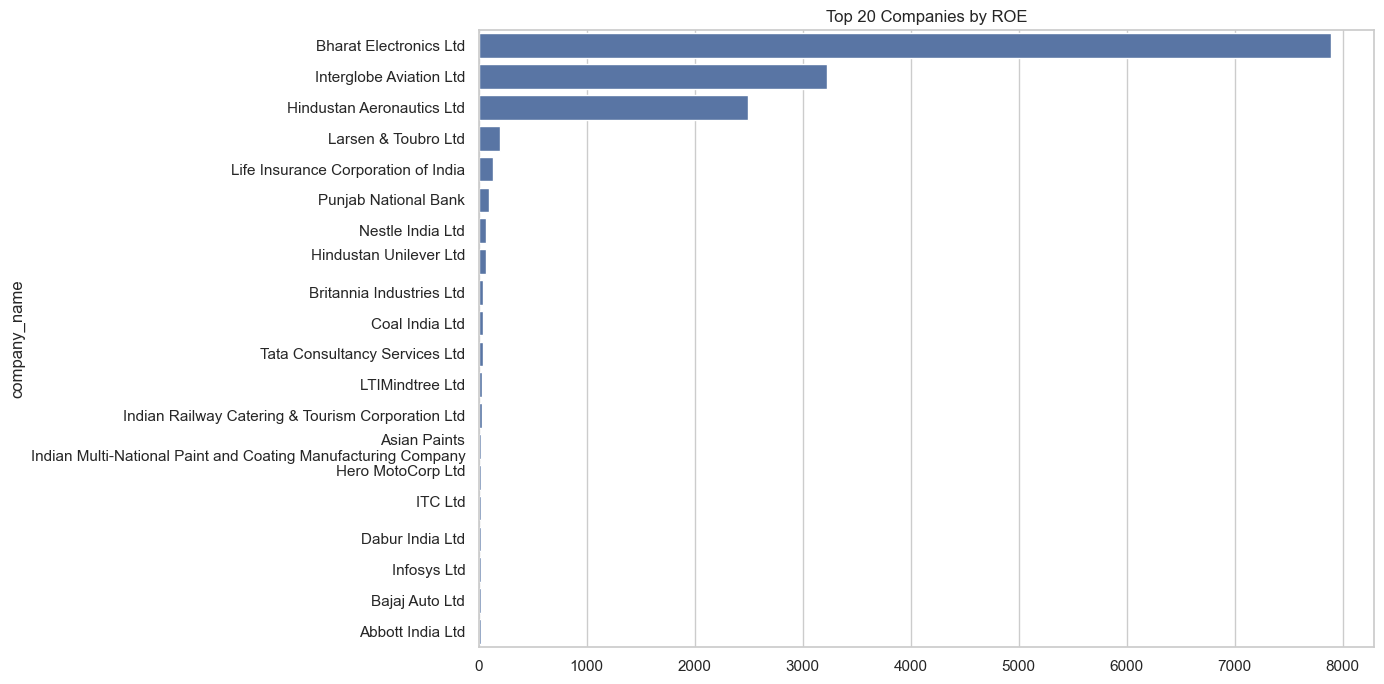

company_name
Bharat Electronics Ltd                                                         7893.885000
Interglobe Aviation Ltd                                                        3229.945833
Hindustan Aeronautics Ltd                                                      2498.978750
Larsen & Toubro Ltd                                                             198.903333
Life Insurance Corporation of India                                             133.611667
Punjab National Bank                                                             95.256667
Nestle India Ltd                                                                 72.542500
Hindustan Unilever Ltd\n                                                         65.858333
Britannia Industries Ltd                                                         45.260000
Coal India Ltd                                                                   42.455833
Tata Consultancy Services Ltd                                                

In [45]:
top_roe = (
    df.groupby("company_name")["return_on_equity_pct"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14,7))

sns.barplot(

    x=top_roe.values,

    y=top_roe.index

)

plt.title("Top 20 Companies by ROE")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top20_roe.png",
    dpi=300
)

plt.show()

top_roe

## Top 20 Largest Market Cap Companies

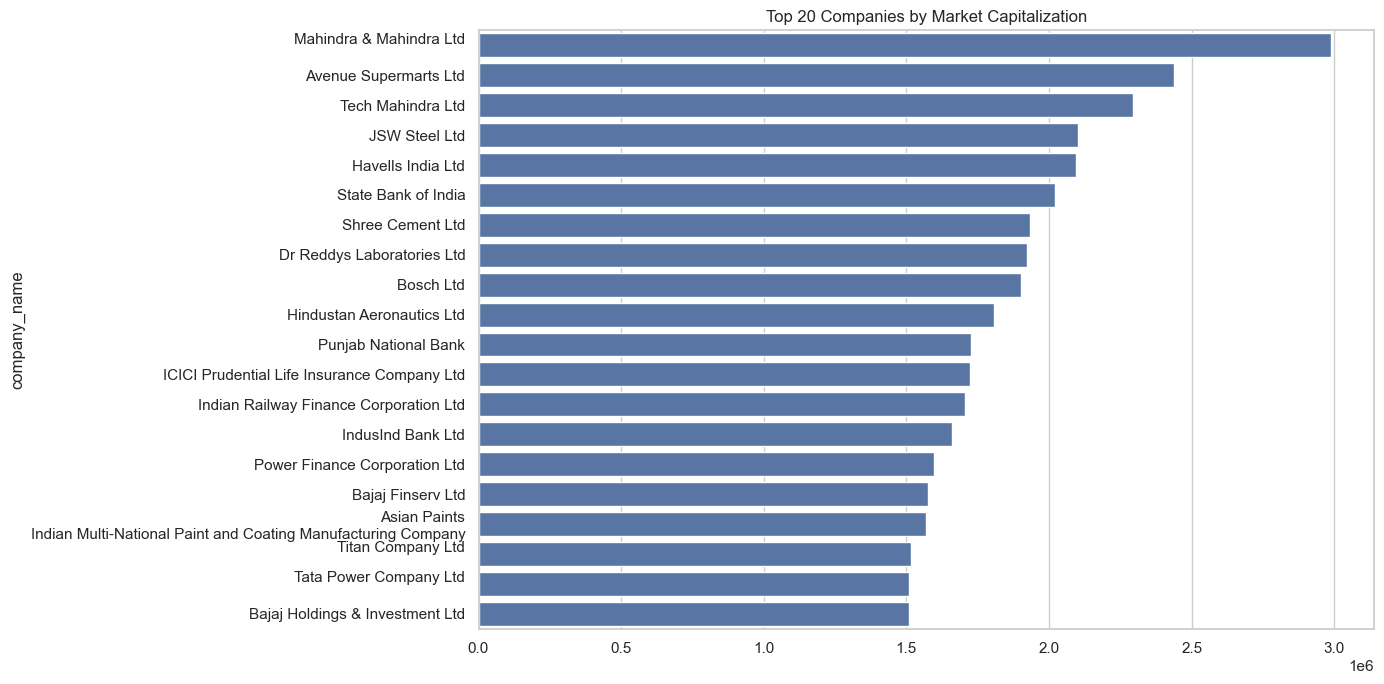

company_name
Mahindra & Mahindra Ltd\n                                                      2.989720e+06
Avenue Supermarts Ltd                                                          2.439395e+06
Tech Mahindra Ltd                                                              2.293601e+06
JSW Steel Ltd                                                                  2.103032e+06
Havells India Ltd                                                              2.095757e+06
State Bank of India                                                            2.021970e+06
Shree Cement Ltd                                                               1.932705e+06
Dr Reddys Laboratories Ltd                                                     1.924076e+06
Bosch Ltd                                                                      1.900292e+06
Hindustan Aeronautics Ltd                                                      1.806332e+06
Punjab National Bank                                               

In [46]:
top_marketcap = (
    df.groupby("company_name")["market_cap_crore"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14,7))

sns.barplot(

    x=top_marketcap.values,

    y=top_marketcap.index

)

plt.title("Top 20 Companies by Market Capitalization")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top20_marketcap.png",
    dpi=300
)

plt.show()

top_marketcap

### Module 6 — Advanced Outlier Analysis

## Z-Score Outlier Detection

In [47]:
from scipy.stats import zscore

outlier_features = [

    "net_profit_margin_pct",
    "return_on_equity_pct",
    "market_cap_crore",
    "financial_strength_score",
    "free_cash_flow_cr"

]

zscore_summary = []

for col in outlier_features:

    temp = df[col].dropna()

    z = np.abs(zscore(temp))

    count = (z > 3).sum()

    zscore_summary.append({

        "Feature": col,

        "ZScore_Outliers": count

    })

zscore_df = pd.DataFrame(zscore_summary)

zscore_df

,Feature,ZScore_Outliers
0,net_profit_margin_pct,78
1,return_on_equity_pct,78
2,market_cap_crore,47
3,financial_strength_score,0
4,free_cash_flow_cr,144


## Top Positive Outliers

In [48]:
top_outliers = df.nlargest(

    20,

    "financial_strength_score"

)[

    [

        "company_name",

        "financial_strength_score",

        "return_on_equity_pct",

        "market_cap_crore",

        "net_profit_margin_pct"

    ]

]

top_outliers

,company_name,financial_strength_score,return_on_equity_pct,market_cap_crore,net_profit_margin_pct
126,Abbott India Ltd,12.0,32.47,844312.98,20.53
127,Abbott India Ltd,12.0,32.47,923674.33,20.53
128,Abbott India Ltd,12.0,32.47,1020674.09,20.53
129,Abbott India Ltd,12.0,32.47,1185994.82,20.53
130,Abbott India Ltd,12.0,32.47,1161513.28,20.53
131,Abbott India Ltd,12.0,32.47,1536236.24,20.53
132,Abbott India Ltd,12.0,32.47,844312.98,20.53
133,Abbott India Ltd,12.0,32.47,923674.33,20.53
134,Abbott India Ltd,12.0,32.47,1020674.09,20.53
135,Abbott India Ltd,12.0,32.47,1185994.82,20.53


## Bottom Companies

In [49]:
bottom_outliers = df.nsmallest(

    20,

    "financial_strength_score"

)[

    [

        "company_name",

        "financial_strength_score",

        "return_on_equity_pct",

        "market_cap_crore",

        "net_profit_margin_pct"

    ]

]

bottom_outliers

,company_name,financial_strength_score,return_on_equity_pct,market_cap_crore,net_profit_margin_pct
144,Adani Energy Solutions Ltd,3.0,-0.65,171905.69,-5.34
145,Adani Energy Solutions Ltd,3.0,-0.65,217135.25,-5.34
146,Adani Energy Solutions Ltd,3.0,-0.65,275655.59,-5.34
147,Adani Energy Solutions Ltd,3.0,-0.65,306303.52,-5.34
148,Adani Energy Solutions Ltd,3.0,-0.65,263283.51,-5.34
149,Adani Energy Solutions Ltd,3.0,-0.65,348517.36,-5.34
276,Adani Green Energy Ltd,3.0,-3.91,485373.12,-9.36
277,Adani Green Energy Ltd,3.0,-3.91,517543.72,-9.36
278,Adani Green Energy Ltd,3.0,-3.91,519085.00,-9.36
279,Adani Green Energy Ltd,3.0,-3.91,495446.05,-9.36


### Module 7 — Business Insights

In [50]:
print("="*80)
print("TOP 10 SECTORS BY FINANCIAL STRENGTH")
print("="*80)

display(

    df.groupby("broad_sector")["financial_strength_score"]

    .mean()

    .sort_values(ascending=False)

    .head(10)

)

print("="*80)
print("TOP 10 COMPANIES BY ROE")
print("="*80)

display(

    df.groupby("company_name")["return_on_equity_pct"]

    .mean()

    .sort_values(ascending=False)

    .head(10)

)

print("="*80)
print("TOP 10 COMPANIES BY MARKET CAP")
print("="*80)

display(

    df.groupby("company_name")["market_cap_crore"]

    .mean()

    .sort_values(ascending=False)

    .head(10)

)

print("="*80)
print("TOP 10 COMPANIES BY FINANCIAL STRENGTH")
print("="*80)

display(

    df.groupby("company_name")["financial_strength_score"]

    .mean()

    .sort_values(ascending=False)

    .head(10)

)

TOP 10 SECTORS BY FINANCIAL STRENGTH


broad_sector
Information Technology    10.619718
Consumer Staples          10.059524
Healthcare                 9.000000
Industrials                8.827338
Consumer Discretionary     8.548023
Materials                  8.474576
Financials                 7.130584
Energy                     7.036810
Communication Services     6.958333
Real Estate                6.952381
Name: financial_strength_score, dtype: float64

TOP 10 COMPANIES BY ROE


company_name
Bharat Electronics Ltd                 7893.885000
Interglobe Aviation Ltd                3229.945833
Hindustan Aeronautics Ltd              2498.978750
Larsen & Toubro Ltd                     198.903333
Life Insurance Corporation of India     133.611667
Punjab National Bank                     95.256667
Nestle India Ltd                         72.542500
Hindustan Unilever Ltd\n                 65.858333
Britannia Industries Ltd                 45.260000
Coal India Ltd                           42.455833
Name: return_on_equity_pct, dtype: float64

TOP 10 COMPANIES BY MARKET CAP


company_name
Mahindra & Mahindra Ltd\n     2.989720e+06
Avenue Supermarts Ltd         2.439395e+06
Tech Mahindra Ltd             2.293601e+06
JSW Steel Ltd                 2.103032e+06
Havells India Ltd             2.095757e+06
State Bank of India           2.021970e+06
Shree Cement Ltd              1.932705e+06
Dr Reddys Laboratories Ltd    1.924076e+06
Bosch Ltd                     1.900292e+06
Hindustan Aeronautics Ltd     1.806332e+06
Name: market_cap_crore, dtype: float64

TOP 10 COMPANIES BY FINANCIAL STRENGTH


company_name
Tata Consultancy Services Ltd                                                  11.750000
ITC Ltd\n                                                                      11.416667
Coal India Ltd                                                                 11.250000
Hindustan Aeronautics Ltd                                                      11.250000
Indian Railway Catering & Tourism Corporation Ltd                              11.200000
LTIMindtree Ltd                                                                11.000000
Divis Laboratories Ltd                                                         11.000000
Infosys Ltd                                                                    10.916667
Nestle India Ltd                                                               10.750000
Asian Paints\nIndian Multi-National Paint and Coating Manufacturing Company    10.750000
Name: financial_strength_score, dtype: float64

### Module 8 — Export EDA Summary

In [51]:
eda_summary = {

    "Rows": len(df),

    "Columns": len(df.columns),

    "Duplicate Rows": int(df.duplicated().sum()),

    "Numeric Columns": len(numeric_cols),

    "Categorical Columns": len(categorical_cols),

    "Missing Values": int(df.isnull().sum().sum())

}

summary_df = pd.DataFrame(

    eda_summary.items(),

    columns=[

        "Metric",

        "Value"

    ]

)

summary_df

,Metric,Value
0,Rows,6972
1,Columns,72
2,Duplicate Rows,0
3,Numeric Columns,51
4,Categorical Columns,21
5,Missing Values,2028


In [52]:
summary_df.to_csv(

    "../reports/eda_summary.csv",

    index=False

)

distribution_summary.to_csv(

    "../reports/distribution_statistics.csv"

)

outlier_df.to_csv(

    "../reports/outlier_summary.csv",

    index=False

)

corr_matrix.to_csv(

    "../reports/correlation_matrix.csv"

)

print("EDA Reports Saved Successfully!")

EDA Reports Saved Successfully!


In [53]:
conn.close()

print("Database Connection Closed.")

Database Connection Closed.
